In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# REQUIREMENTS

In [2]:
# Uncomment if running in Google Colab
!pip install openmeteo-requests requests-cache retry-requests keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.0/711.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.0 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


# IMPORTS

In [3]:
import os
import json
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import requests_cache
from retry_requests import retry
import openmeteo_requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber, MeanSquaredError

import joblib

# Optional tuner (required only if RUN_HYPERPARAM_TUNING=True)
try:
    import keras_tuner as kt
except ImportError:
    kt = None
    print("keras_tuner not installed. Install it if you want hyperparameter tuning.")

#PLOT STYLE

In [4]:
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "font.size": 11,
})

#CONSTANTS

In [5]:
# =========================
# PROJECT / PATHS
# =========================
# If using Colab + Drive, mount first:
# from google.colab import drive
# drive.mount('/content/drive')

USE_COLAB_DRIVE = True  # set True if using Google Drive paths below

if USE_COLAB_DRIVE:
    BASE_DIR = "/content/drive/MyDrive/THESIS/THESIS Google Colab/Models"
else:
    BASE_DIR = "./models"

PROJECT_NAMES = ["iloilo_lstm_daily_weather_direct2_x7", "iloilo_lstm_daily_weather_direct2_x14", "iloilo_lstm_daily_weather_direct2_x21", "iloilo_lstm_daily_weather_direct2_x30", "iloilo_lstm_daily_weather_direct2_huber_x7", "iloilo_lstm_daily_weather_direct2_huber_x14", "iloilo_lstm_daily_weather_direct2_huber_x21", "iloilo_lstm_daily_weather_direct2_huber_x30"]
PROJECT_PATHS = [os.path.join(BASE_DIR, name) for name in PROJECT_NAMES]
PROJECT_ARTIFACTS = [os.path.join(path, "artifacts") for path in PROJECT_PATHS]

TRIAL_PATHS = [os.path.join(path, "tuner_trials_summary.csv") for path in PROJECT_ARTIFACTS]
MODEL_DIRS = [os.path.join(path, "final_model") for path in PROJECT_PATHS]
MODEL_PATHS = [os.path.join(directory, "LSTM_Weather_Forecast_Direct2.keras") for directory in MODEL_DIRS]
X_SCALER_PATH = [os.path.join(directory, "x_scaler.pkl") for directory in MODEL_DIRS]
Y_SCALER_PATH = [os.path.join(directory, "y_scaler.pkl") for directory in MODEL_DIRS]
CONFIG_PATHS = [os.path.join(directory, "config.json") for directory in MODEL_DIRS]

# =========================
# MODELING GOAL
# =========================
TARGET_HORIZON = 2  # predict next 2 days
N_STEPS = 7        # try 7, 14, 21, 30 later (recommended tuning target)

# =========================
# SPLITS (chronological by target date)
# =========================
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

# =========================
# LOCATION / DATA
# =========================
LATITUDE = 10.6969
LONGITUDE = 122.5644
TIMEZONE = "Asia/Manila"  # use local timezone explicitly
TRAIN_START_DATE = "2014-01-01"
TRAIN_END_DATE = "2024-12-31"   # adjust if needed

# Core target variables (same as your project)
TARGET_COLS_RAW = [
    "temperature_2m_min",
    "temperature_2m_max",
    "rain_sum",
    "wind_speed_10m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "sunshine_duration",  # stored in hours after preprocessing
]

FEATURE_DISPLAY_NAMES = [
    "Min Temperature",
    "Max Temperature",
    "Rain Sum",
    "Mean Wind Speed",
    "Mean Relative Humidity",
    "Mean Dew Point",
    "Sunshine Duration",
]

# Utility Functions (Fetch, Preprocess, Feature Engineering)

In [6]:
def fetch_openmeteo_daily_archive(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    timezone: str = "Asia/Manila",
) -> pd.DataFrame:
    """Fetch daily historical weather from Open-Meteo archive API."""
    cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_min",
            "temperature_2m_max",
            "rain_sum",
            "wind_speed_10m_mean",
            "relative_humidity_2m_mean",
            "dew_point_2m_mean",
            "sunshine_duration",
        ],
        "timezone": timezone,  # local timezone to reduce date confusion
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    daily = response.Daily()

    data = {
        "date": pd.date_range(
            start=pd.to_datetime(daily.Time(), unit="s", utc=True),
            end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive="left",
        ),
        "temperature_2m_min": daily.Variables(0).ValuesAsNumpy(),
        "temperature_2m_max": daily.Variables(1).ValuesAsNumpy(),
        "rain_sum": daily.Variables(2).ValuesAsNumpy(),
        "wind_speed_10m_mean": daily.Variables(3).ValuesAsNumpy(),
        "relative_humidity_2m_mean": daily.Variables(4).ValuesAsNumpy(),
        "dew_point_2m_mean": daily.Variables(5).ValuesAsNumpy(),
        "sunshine_duration": daily.Variables(6).ValuesAsNumpy(),  # seconds from API
    }

    df = pd.DataFrame(data)
    return df


def add_calendar_features(index: pd.DatetimeIndex) -> pd.DataFrame:
    """Cyclical calendar features for seasonality."""
    # convert to local timezone for day-of-year interpretation
    idx_local = index.tz_convert(TIMEZONE) if index.tz is not None else index.tz_localize(TIMEZONE)
    day_of_year = idx_local.dayofyear.astype(float)
    month = idx_local.month.astype(float)

    cal = pd.DataFrame(index=index)
    cal["doy_sin"] = np.sin(2 * np.pi * day_of_year / 366.0)
    cal["doy_cos"] = np.cos(2 * np.pi * day_of_year / 366.0)
    cal["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    cal["month_cos"] = np.cos(2 * np.pi * month / 12.0)
    return cal


def preprocess_daily_weather(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess raw Open-Meteo daily data into modeling-ready dataframe."""
    df = raw_df.copy()

    # Ensure datetime + timezone handling
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df = df.sort_values("date").drop_duplicates("date")
    df = df.set_index("date")

    # Convert sunshine seconds -> hours
    df["sunshine_duration"] = df["sunshine_duration"] / 3600.0

    # Fill missing sunshine using time interpolation (keep your original idea)
    if "sunshine_duration" in df.columns:
        df["sunshine_duration"] = df["sunshine_duration"].interpolate(method="time").bfill().ffill()

    # Basic cleaning: avoid negatives for variables that should be non-negative
    df["rain_sum"] = df["rain_sum"].clip(lower=0)
    df["sunshine_duration"] = df["sunshine_duration"].clip(lower=0)

    # Optional rain transform for better learning on spikes
    df["rain_sum_log1p"] = np.log1p(df["rain_sum"])

    # Add calendar features
    cal = add_calendar_features(df.index)
    df = pd.concat([df, cal], axis=1)

    # Drop any remaining missing rows
    df = df.dropna().copy()
    return df


def inverse_target_postprocess(y_pred_target_raw: np.ndarray, target_cols_transformed: List[str]) -> np.ndarray:
    """Convert transformed target columns back to original physical units (rain expm1, clipping)."""
    out = pd.DataFrame(y_pred_target_raw, columns=target_cols_transformed)

    # Reverse rain transform
    if "rain_sum_log1p" in out.columns:
        out["rain_sum"] = np.expm1(out["rain_sum_log1p"]).clip(lower=0)
        out = out.drop(columns=["rain_sum_log1p"])

    # Physical clipping / sanity
    if "sunshine_duration" in out.columns:
        out["sunshine_duration"] = out["sunshine_duration"].clip(lower=0)
    if "relative_humidity_2m_mean" in out.columns:
        out["relative_humidity_2m_mean"] = out["relative_humidity_2m_mean"].clip(lower=0, upper=100)
    if "rain_sum" in out.columns:
        out["rain_sum"] = out["rain_sum"].clip(lower=0)

    # Enforce max temp >= min temp (optional but practical)
    if {"temperature_2m_min", "temperature_2m_max"}.issubset(out.columns):
        mask = out["temperature_2m_max"] < out["temperature_2m_min"]
        if mask.any():
            swapped_max = out.loc[mask, "temperature_2m_min"].values
            out.loc[mask, "temperature_2m_min"] = out.loc[mask, "temperature_2m_max"].values
            out.loc[mask, "temperature_2m_max"] = swapped_max

    # Return in raw target order
    final_cols = [
        "temperature_2m_min",
        "temperature_2m_max",
        "rain_sum",
        "wind_speed_10m_mean",
        "relative_humidity_2m_mean",
        "dew_point_2m_mean",
        "sunshine_duration",
    ]
    return out[final_cols].to_numpy()

def display_history(hist):
  hist = pd.DataFrame(hist.history)
  display(hist.tail())

  for metric in ["loss", "mae", "rmse"]:
      plt.figure(figsize=(10,4))
      plt.plot(hist[metric], label=f"train_{metric}")
      if f"val_{metric}" in hist.columns:
          plt.plot(hist[f"val_{metric}"], label=f"val_{metric}")
      plt.title(f"Training Curve - {metric.upper()}")
      plt.xlabel("Epoch")
      plt.ylabel(metric.upper())
      plt.legend()
      plt.show()

In [7]:
def csv_to_dataframe(file_path):
    """
    Reads a CSV file into a Pandas DataFrame with validation and error handling.

    :param file_path: Path to the CSV file
    :return: Pandas DataFrame or None if an error occurs
    """
    # Validate file existence
    if not os.path.isfile(file_path):
        print(f"Error: File '{file_path}' does not exist.")
        return None

    # Validate file extension
    if not file_path.lower().endswith(".csv"):
        print("Error: The file must have a .csv extension.")
        return None

    try:
        # Read CSV into DataFrame
        df = pd.read_csv(file_path)
        print(f"CSV loaded successfully. Shape: {df.shape}")
        return df
    except pd.errors.EmptyDataError:
        print("Error: The CSV file is empty.")
    except pd.errors.ParserError as e:
        print(f"Error parsing CSV: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

    return None

# Sequence Creation + Splitting Helpers

In [8]:
def create_multihorizon_sequences(
    X_scaled: np.ndarray,
    y_scaled: np.ndarray,
    dates_index: pd.DatetimeIndex,
    n_steps: int,
    horizon: int,
):
    """
    Create direct multi-horizon sequences.
    X_seq shape: (n_samples, n_steps, n_features)
    y_seq shape: (n_samples, horizon, n_targets)

    target_dates[i] = array of length horizon with the actual dates for y_seq[i]
    """
    X_seq, y_seq, target_dates = [], [], []

    n_rows = len(X_scaled)
    for start in range(n_rows - n_steps - horizon + 1):
        end_x = start + n_steps
        end_y = end_x + horizon

        X_seq.append(X_scaled[start:end_x])
        y_seq.append(y_scaled[end_x:end_y])
        target_dates.append(dates_index[end_x:end_y])

    return np.asarray(X_seq), np.asarray(y_seq), np.asarray(target_dates, dtype=object)


def chronological_row_splits(n_rows: int, train_ratio: float, val_ratio: float, test_ratio: float):
    assert n_rows > 10
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)
    # test gets the remainder
    return train_end, val_end


def fit_scalers_on_train_only(
    df_model: pd.DataFrame,
    feature_cols_model: List[str],
    target_cols_model: List[str],
    train_end_row: int,
):
    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    x_scaler.fit(df_model.iloc[:train_end_row][feature_cols_model].values)
    y_scaler.fit(df_model.iloc[:train_end_row][target_cols_model].values)

    X_scaled = x_scaler.transform(df_model[feature_cols_model].values)
    y_scaled = y_scaler.transform(df_model[target_cols_model].values)

    return X_scaled, y_scaled, x_scaler, y_scaler


def split_sequences_by_target_date(
    X_seq: np.ndarray,
    y_seq: np.ndarray,
    target_dates: np.ndarray,
    train_end_date: pd.Timestamp,
    val_end_date: pd.Timestamp,
):
    """
    Split sequence samples based on the FIRST target date (horizon-1 date can spill within same partition).
    """
    first_target_dates = pd.to_datetime([td[0] for td in target_dates])

    train_mask = first_target_dates <= train_end_date
    val_mask = (first_target_dates > train_end_date) & (first_target_dates <= val_end_date)
    test_mask = first_target_dates > val_end_date

    splits = {
        "train": (X_seq[train_mask], y_seq[train_mask], target_dates[train_mask]),
        "val": (X_seq[val_mask], y_seq[val_mask], target_dates[val_mask]),
        "test": (X_seq[test_mask], y_seq[test_mask], target_dates[test_mask]),
    }
    return splits

## 7) Model Builder (LSTM-Only, Direct 2-Day Output)

In [9]:
@tf.keras.utils.register_keras_serializable()
class R2Score3D(tf.keras.metrics.Metric):
    def __init__(self, name='r2', **kwargs):
        super().__init__(name=name, **kwargs)
        self.r2_metric = tf.keras.metrics.R2Score()

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Flatten (batch, horizon, features) -> (batch * horizon, features)
        # or just flatten completely to 1D if we want a global aggregate
        # Standard R2Score expects (samples, features)
        y_true_flat = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred_flat = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        self.r2_metric.update_state(y_true_flat, y_pred_flat, sample_weight=sample_weight)

    def result(self):
        return self.r2_metric.result()

    def reset_state(self):
        self.r2_metric.reset_state()

def build_lstm_direct2_model(
    n_steps: int,
    n_features: int,
    n_targets: int,
    horizon: int = 2,
    lstm_units_1: int = 64,
    lstm_units_2: int = 32,
    dropout_1: float = 0.15,
    dropout_2: float = 0.10,
    dense_units: int = 64,
    learning_rate: float = 1e-3,
    use_huber_loss: bool = True,
) -> tf.keras.Model:
    model = Sequential(name="LSTM_Direct2_Iloilo")
    model.add(LSTM(lstm_units_1, return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(Dropout(dropout_1))
    model.add(LSTM(lstm_units_2, return_sequences=False))
    model.add(Dropout(dropout_2))
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dense(horizon * n_targets)) # horizon: 2, n_targets: 7
    model.add(Reshape((horizon, n_targets)))

    loss_fn = Huber() if use_huber_loss else MeanSquaredError()
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae"),
                 tf.keras.metrics.RootMeanSquaredError(name="rmse"),
                 R2Score3D(name="r2")]
    )
    return model

# Fetch Historical Data

In [10]:
raw_df = fetch_openmeteo_daily_archive(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    start_date=TRAIN_START_DATE,
    end_date=TRAIN_END_DATE,
    timezone=TIMEZONE,
)

print(raw_df.head())
print(raw_df.tail())
print(f"Rows fetched: {len(raw_df)}")

                       date  temperature_2m_min  temperature_2m_max  rain_sum  \
0 2013-12-31 16:00:00+00:00           24.729500           27.479500  0.400000   
1 2014-01-01 16:00:00+00:00           24.629501           27.329498  7.399999   
2 2014-01-02 16:00:00+00:00           24.629501           28.879501  1.200000   
3 2014-01-03 16:00:00+00:00           24.629501           29.179501  0.100000   
4 2014-01-04 16:00:00+00:00           24.379501           27.529499  0.900000   

   wind_speed_10m_mean  relative_humidity_2m_mean  dew_point_2m_mean  \
0            20.971268                  86.795143          23.458670   
1            21.947840                  86.367065          23.292000   
2            17.666321                  85.203285          23.352415   
3            16.192158                  83.461899          23.150335   
4            20.674368                  86.114296          23.141998   

   sunshine_duration  
0       24635.158203  
1       35137.902344  
2       323

## 9) Preprocess + Build Modeling Columns

In [11]:
df = preprocess_daily_weather(raw_df)

# Inputs to the model:
# - raw weather targets EXCEPT we use rain_sum_log1p instead of rain_sum
# - seasonal calendar features
FEATURE_COLS_MODEL = [
    "temperature_2m_min",
    "temperature_2m_max",
    "rain_sum_log1p",              # transformed rain for training stability
    "wind_speed_10m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "sunshine_duration",
    "doy_sin", "doy_cos", "month_sin", "month_cos",
]

# Outputs (targets) for direct prediction (2 days x 7 vars)
TARGET_COLS_MODEL = [
    "temperature_2m_min",
    "temperature_2m_max",
    "rain_sum_log1p",              # transformed target during training
    "wind_speed_10m_mean",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "sunshine_duration",
]

print("Data shape:", df.shape)
display(df[FEATURE_COLS_MODEL + ["rain_sum"]].head())

Data shape: (4018, 12)


,temperature_2m_min,temperature_2m_max,rain_sum_log1p,wind_speed_10m_mean,relative_humidity_2m_mean,dew_point_2m_mean,sunshine_duration,doy_sin,doy_cos,month_sin,month_cos,rain_sum
date,,,,,,,,,,,,
2013-12-31 16:00:00+00:00,24.729500,27.479500,0.336472,20.971268,86.795143,23.458670,6.843100,0.017166,0.999853,0.5,0.866025,0.400000
2014-01-01 16:00:00+00:00,24.629501,27.329498,2.128232,21.947840,86.367065,23.292000,9.760529,0.034328,0.999411,0.5,0.866025,7.399999
2014-01-02 16:00:00+00:00,24.629501,28.879501,0.788457,17.666321,85.203285,23.352415,8.991520,0.051479,0.998674,0.5,0.866025,1.200000
2014-01-03 16:00:00+00:00,24.629501,29.179501,0.095310,16.192158,83.461899,23.150335,11.219443,0.068615,0.997643,0.5,0.866025,0.100000
2014-01-04 16:00:00+00:00,24.379501,27.529499,0.641854,20.674368,86.114296,23.141998,10.790619,0.085731,0.996318,0.5,0.866025,0.900000


# Chronological Row Split (before scaling)

In [12]:
n_rows = len(df)
train_end_row, val_end_row = chronological_row_splits(n_rows, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)

train_end_date = df.index[train_end_row - 1]
val_end_date = df.index[val_end_row - 1]

print("Train end row/date:", train_end_row, train_end_date)
print("Val end row/date  :", val_end_row, val_end_date)
print("Test starts       :", df.index[val_end_row])

# Fit scalers on TRAIN ONLY (no leakage)
X_scaled_all, y_scaled_all, x_scaler, y_scaler = fit_scalers_on_train_only(
    df_model=df,
    feature_cols_model=FEATURE_COLS_MODEL,
    target_cols_model=TARGET_COLS_MODEL,
    train_end_row=train_end_row,
)

print("Scaled X shape:", X_scaled_all.shape)
print("Scaled y shape:", y_scaled_all.shape)

Train end row/date: 3214 2022-10-18 16:00:00+00:00
Val end row/date  : 3615 2023-11-23 16:00:00+00:00
Test starts       : 2023-11-24 16:00:00+00:00
Scaled X shape: (4018, 11)
Scaled y shape: (4018, 7)


#Create Direct 2-Day Sequences + Sequence Split

In [13]:
X_seq, y_seq, target_dates = create_multihorizon_sequences(
    X_scaled=X_scaled_all,
    y_scaled=y_scaled_all,
    dates_index=df.index,
    n_steps=N_STEPS,
    horizon=TARGET_HORIZON,
)

splits = split_sequences_by_target_date(
    X_seq=X_seq, y_seq=y_seq, target_dates=target_dates,
    train_end_date=train_end_date,
    val_end_date=val_end_date,
)

X_train, y_train, td_train = splits["train"]
X_val, y_val, td_val = splits["val"]
X_test, y_test, td_test = splits["test"]

print("X_seq:", X_seq.shape, "y_seq:", y_seq.shape)
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

assert X_train.shape[-1] == len(FEATURE_COLS_MODEL)
assert y_train.shape[-1] == len(TARGET_COLS_MODEL)
assert y_train.shape[1] == TARGET_HORIZON

X_seq: (4010, 7, 11) y_seq: (4010, 2, 7)
Train: (3207, 7, 11) (3207, 2, 7)
Val  : (401, 7, 11) (401, 2, 7)
Test : (402, 7, 11) (402, 2, 7)


In [14]:
def flatten_horizon_predictions(y_true_seq: np.ndarray, y_pred_seq: np.ndarray):
    """Flatten (samples, horizon, features) -> (samples*horizon, features)."""
    y_true_flat = y_true_seq.reshape(-1, y_true_seq.shape[-1])
    y_pred_flat = y_pred_seq.reshape(-1, y_pred_seq.shape[-1])
    return y_true_flat, y_pred_flat


def inverse_targets_to_original_units(y_scaled_seq: np.ndarray, y_scaler: MinMaxScaler, target_cols_model: List[str]):
    """Inverse y scaling and postprocess to raw physical target units."""
    shape = y_scaled_seq.shape
    y_flat = y_scaled_seq.reshape(-1, shape[-1])
    y_unscaled_transformed = y_scaler.inverse_transform(y_flat)
    y_raw = inverse_target_postprocess(y_unscaled_transformed, target_cols_model)
    y_raw_seq = y_raw.reshape(shape[0], shape[1], -1)
    return y_raw_seq


def evaluate_direct2(
    model: tf.keras.Model,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
    y_scaler: MinMaxScaler,
    target_cols_model: List[str],
    feature_display_names: List[str],
):
    y_pred_scaled = model.predict(X_eval, verbose=2)


    # Evaluate on scaled space (no transformation)
    y_true = y_eval
    y_pred = y_pred_scaled

     # Metrics per horizon + feature
    rows = []
    for h in range(y_true.shape[1]):
        for i, fname in enumerate(feature_display_names):
            yt = y_true[:, h, i]
            yp = y_pred[:, h, i]
            rows.append({
                "horizon": h + 1,
                "feature": fname,
                "MAE": mean_absolute_error(yt, yp),
                "RMSE": np.sqrt(mean_squared_error(yt, yp)),
                "R2": r2_score(yt, yp),
            })

    df_metrics = pd.DataFrame(rows)

     # Overall (flatten all horizons + features into one matrix; average feature scales matter, so also report feature-mean)
    y_true_flat, y_pred_flat = flatten_horizon_predictions(y_true, y_pred)

    overall = {
         "MAE_macro_over_features": np.mean([
             mean_absolute_error(y_true_flat[:, i], y_pred_flat[:, i]) for i in range(y_true_flat.shape[1])
         ]),
         "RMSE_macro_over_features": np.mean([
             np.sqrt(mean_squared_error(y_true_flat[:, i], y_pred_flat[:, i])) for i in range(y_true_flat.shape[1])
         ]),
         "R2_macro_over_features": np.mean([
             r2_score(y_true_flat[:, i], y_pred_flat[:, i]) for i in range(y_true_flat.shape[1])
         ]),
     }

    return y_true, y_pred, df_metrics, overall

In [15]:
for model in MODEL_PATHS:
  model = tf.keras.models.load_model(model)
  model.summary()
  y_true_test_raw, y_pred_test_raw, test_metrics_df, test_overall = evaluate_direct2(
    model=model,
    X_eval=X_test,
    y_eval=y_test,
    y_scaler=y_scaler,
    target_cols_model=TARGET_COLS_MODEL,
    feature_display_names=FEATURE_DISPLAY_NAMES,
  )

  print("Test Overall (macro across features):")
  print(test_overall)
  display(test_metrics_df)

  display(
      test_metrics_df.groupby("horizon")[["MAE", "RMSE", "R2"]].mean().reset_index()
  )

  display(
      test_metrics_df.pivot(index="feature", columns="horizon", values="R2")
  )

Model: "LSTM_Direct2_Iloilo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1502 (LSTM)                │ (None, 7, 384)         │       608,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1502 (Dropout)          │ (None, 7, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1503 (LSTM)                │ (None, 128)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1503 (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1502 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1503 (Dense)              │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_751 (Reshape)           │ (None, 2, 7)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,640,236 (10.07 MB)

 Trainable params: 880,078 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

...

 Optimizer params: 2,451,870 (9.35 MB)

13/13 - 0s - 26ms/step
Test Overall (macro across features):
{'MAE_macro_over_features': np.float64(0.09965189546346664), 'RMSE_macro_over_features': np.float64(0.13240533026990425), 'R2_macro_over_features': np.float64(0.5512065802301679)}


,horizon,feature,MAE,RMSE,R2
0,1,Min Temperature,0.065054,0.082471,0.589196
1,1,Max Temperature,0.120428,0.143675,0.505004
2,1,Rain Sum,0.108722,0.140073,0.526454
3,1,Mean Wind Speed,0.085499,0.112844,0.757572
4,1,Mean Relative Humidity,0.103611,0.135198,0.758240
5,1,Mean Dew Point,0.054983,0.081249,0.761244
6,1,Sunshine Duration,0.102126,0.162570,0.378035
7,2,Min Temperature,0.070778,0.088795,0.523493
8,2,Max Temperature,0.144379,0.168160,0.321989
9,2,Rain Sum,0.122222,0.151755,0.443757


,horizon,MAE,RMSE,R2
0,1,0.091489,0.122583,0.610821
1,2,0.107815,0.141374,0.491593


horizon,1,2
feature,,
Max Temperature,0.505004,0.321989
Mean Dew Point,0.761244,0.673495
Mean Relative Humidity,0.758240,0.698935
Mean Wind Speed,0.757572,0.545350
Min Temperature,0.589196,0.523493
Rain Sum,0.526454,0.443757
Sunshine Duration,0.378035,0.234137


In [17]:
comparison_rows = []

for model_name, model_path in zip(PROJECT_NAMES, MODEL_PATHS):
    tf.keras.backend.clear_session()
    model = tf.keras.models.load_model(model_path)

    _, _, test_metrics_df, test_overall = evaluate_direct2(
        model=model,
        X_eval=X_test,
        y_eval=y_test,
        y_scaler=y_scaler,
        target_cols_model=TARGET_COLS_MODEL,
        feature_display_names=FEATURE_DISPLAY_NAMES,
    )

    metric_avg = test_metrics_df[["MAE", "RMSE", "R2"]].mean()

    horizon_avg = (
        test_metrics_df.groupby("horizon", as_index=True)[["MAE", "RMSE", "R2"]]
        .mean()
        .stack()
    )

    horizon_avg.index = [f"H{int(h)}_{metric}" for h, metric in horizon_avg.index]

    comparison_rows.append({
        "Model": model_name,
        "Avg_MAE": metric_avg["MAE"],
        "Avg_RMSE": metric_avg["RMSE"],
        "Avg_R2": metric_avg["R2"],
        "Overall_MAE_macro": test_overall["MAE_macro_over_features"],
        "Overall_RMSE_macro": test_overall["RMSE_macro_over_features"],
        "Overall_R2_macro": test_overall["R2_macro_over_features"],
        **horizon_avg.to_dict(),
    })

    del model

model_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        by=["Overall_RMSE_macro", "Overall_MAE_macro", "Overall_R2_macro"],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

display(model_comparison_df)


13/13 - 0s - 27ms/step
13/13 - 0s - 27ms/step
13/13 - 0s - 27ms/step
13/13 - 0s - 27ms/step
13/13 - 0s - 27ms/step
13/13 - 0s - 27ms/step
13/13 - 0s - 28ms/step
13/13 - 0s - 28ms/step


,Model,Avg_MAE,Avg_RMSE,Avg_R2,Overall_MAE_macro,Overall_RMSE_macro,Overall_R2_macro,H1_MAE,H1_RMSE,H1_R2,H2_MAE,H2_RMSE,H2_R2
0,iloilo_lstm_daily_weather_direct2_x14,0.089216,0.119910,0.613322,0.089216,0.120334,0.613322,0.082454,0.111500,0.662065,0.095979,0.128320,0.564578
1,iloilo_lstm_daily_weather_direct2_huber_x7,0.093931,0.124445,0.585727,0.093931,0.124839,0.585728,0.087437,0.116202,0.636526,0.100426,0.132688,0.534929
2,iloilo_lstm_daily_weather_direct2_x7,0.095163,0.126234,0.572548,0.095163,0.126670,0.572551,0.088484,0.117676,0.629053,0.101842,0.134792,0.516044
3,iloilo_lstm_daily_weather_direct2_x21,0.097992,0.127591,0.571834,0.097992,0.128110,0.571832,0.089518,0.117913,0.629374,0.106467,0.137270,0.514293
4,iloilo_lstm_daily_weather_direct2_x30,0.098154,0.130052,0.559219,0.098154,0.130361,0.559219,0.092062,0.123012,0.603055,0.104247,0.137092,0.515383
5,iloilo_lstm_daily_weather_direct2_huber_x30,0.099652,0.131978,0.551207,0.099652,0.132405,0.551207,0.091489,0.122583,0.610821,0.107815,0.141374,0.491593
6,iloilo_lstm_daily_weather_direct2_huber_x21,0.101916,0.132216,0.542556,0.101916,0.132607,0.542554,0.094570,0.124072,0.591784,0.109261,0.140361,0.493327
7,iloilo_lstm_daily_weather_direct2_huber_x14,0.115382,0.143580,0.460581,0.115382,0.144177,0.460579,0.106619,0.134379,0.517540,0.124144,0.152782,0.403622


In [18]:
best_model_row = (
    model_comparison_df
    .sort_values(
        by=["Overall_RMSE_macro", "Overall_MAE_macro", "Overall_R2_macro"],
        ascending=[True, True, False],
    )
    .iloc[0]
)

best_model_name = best_model_row["Model"]
best_model_path = MODEL_PATHS[PROJECT_NAMES.index(best_model_name)]
best_model = tf.keras.models.load_model(best_model_path)

print("Best model:")
print(f"Name: {best_model_name}")
print(f"Path: {best_model_path}")
display(best_model_row.to_frame().T)


Best model:
Name: iloilo_lstm_daily_weather_direct2_x14
Path: /content/drive/MyDrive/THESIS/THESIS Google Colab/Models/iloilo_lstm_daily_weather_direct2_x14/final_model/LSTM_Weather_Forecast_Direct2.keras


,Model,Avg_MAE,Avg_RMSE,Avg_R2,Overall_MAE_macro,Overall_RMSE_macro,Overall_R2_macro,H1_MAE,H1_RMSE,H1_R2,H2_MAE,H2_RMSE,H2_R2
0,iloilo_lstm_daily_weather_direct2_x14,0.089216,0.11991,0.613322,0.089216,0.120334,0.613322,0.082454,0.1115,0.662065,0.095979,0.12832,0.564578


CSV loaded successfully. Shape: (150, 11)
CSV loaded successfully. Shape: (150, 11)
CSV loaded successfully. Shape: (150, 11)
CSV loaded successfully. Shape: (150, 11)


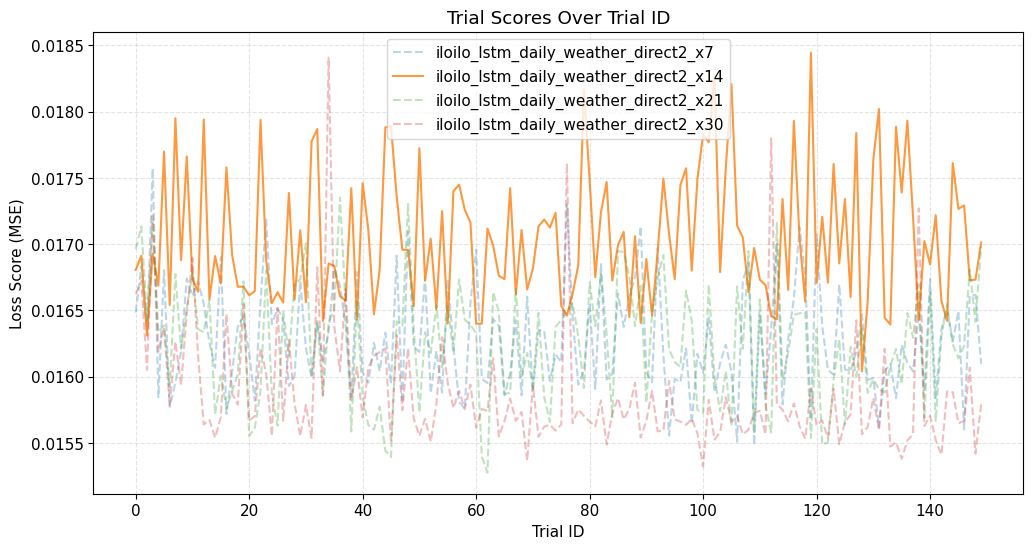

Model: "LSTM_Direct2_Iloilo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 384)         │       608,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 7)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,640,236 (10.07 MB)

 Trainable params: 880,078 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,760,158 (6.71 MB)

In [19]:
plt.figure(figsize=(12, 6))

for name, trial in zip(PROJECT_NAMES, TRIAL_PATHS[:4]):
    trial_df = csv_to_dataframe(trial)
    if trial_df is not None and not trial_df.empty:
        trial_df = trial_df.sort_values(by='trial_id')

        if 'x14' in name:
            plt.plot(trial_df['trial_id'], trial_df['score'], linestyle='-', alpha=0.8, label=name)
        else:
            plt.plot(trial_df['trial_id'], trial_df['score'], linestyle='--', alpha=0.3, label=name)

plt.title('Trial Scores Over Trial ID')
plt.xlabel('Trial ID')
plt.ylabel('Loss Score (MSE)')
plt.legend()
plt.grid(True)
plt.show()

model = tf.keras.models.load_model(MODEL_PATHS[1])
model.summary()



CSV loaded successfully. Shape: (150, 11)
CSV loaded successfully. Shape: (150, 11)
CSV loaded successfully. Shape: (150, 11)
CSV loaded successfully. Shape: (150, 11)


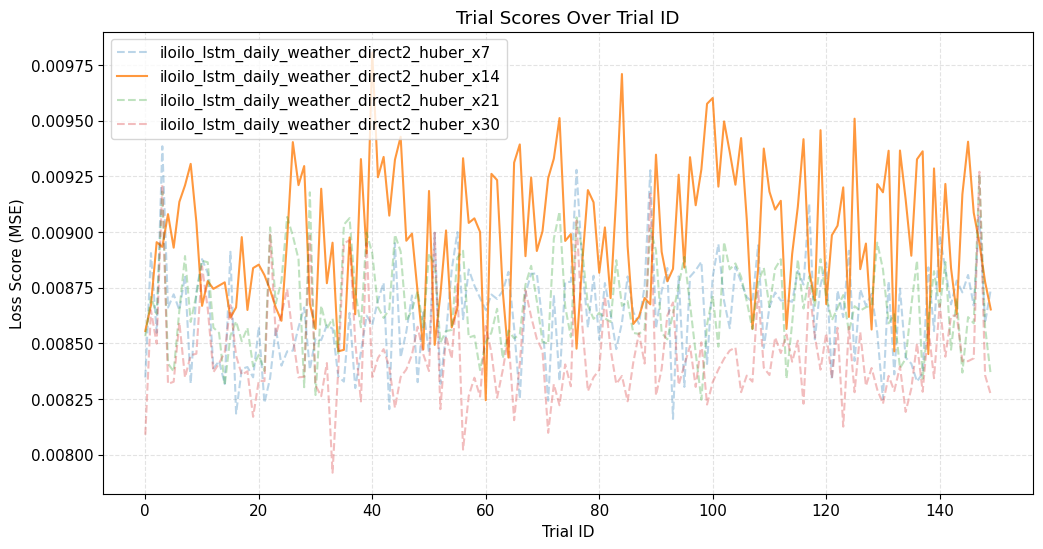

Model: "LSTM_Direct2_Iloilo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 384)         │       608,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 7)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,640,236 (10.07 MB)

 Trainable params: 880,078 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,760,158 (6.71 MB)

In [20]:
plt.figure(figsize=(12, 6))

for name, trial in zip(PROJECT_NAMES[4:], TRIAL_PATHS[4:]):
    trial_df = csv_to_dataframe(trial)
    if trial_df is not None and not trial_df.empty:
        trial_df = trial_df.sort_values(by='trial_id')

        if 'x14' in name:
            plt.plot(trial_df['trial_id'], trial_df['score'], linestyle='-', alpha=0.8, label=name)
        else:
            plt.plot(trial_df['trial_id'], trial_df['score'], linestyle='--', alpha=0.3, label=name)

plt.title('Trial Scores Over Trial ID')
plt.xlabel('Trial ID')
plt.ylabel('Loss Score (MSE)')
plt.legend()
plt.grid(True)
plt.show()

model = tf.keras.models.load_model(MODEL_PATHS[1])
model.summary()

In [23]:
best_model.summary()
y_true_test_raw, y_pred_test_raw, test_metrics_df, test_overall = evaluate_direct2(
  model=model,
  X_eval=X_test,
  y_eval=y_test,
  y_scaler=y_scaler,
  target_cols_model=TARGET_COLS_MODEL,
  feature_display_names=FEATURE_DISPLAY_NAMES,
)

print("Test Overall (macro across features):")
print(test_overall)
display(test_metrics_df)

overall_results_df = pd.DataFrame([test_overall])

combined_results_df = pd.concat(
    [
        test_metrics_df.groupby("horizon")[["MAE", "RMSE", "R2"]]
        .mean()
        .reset_index()
        .assign(Result=lambda df: "Horizon " + df["horizon"].astype(str))
        .drop(columns="horizon")[["Result", "MAE", "RMSE", "R2"]],
        pd.DataFrame(
            [
                {
                    "Result": "Overall",
                    "MAE": test_overall["MAE_macro_over_features"],
                    "RMSE": test_overall["RMSE_macro_over_features"],
                    "R2": test_overall["R2_macro_over_features"],
                }
            ]
        ),
    ],
    ignore_index=True,
)


single_feature_horizon_table = (
    test_metrics_df.groupby(["feature", "horizon"])[["MAE", "RMSE", "R2"]]
    .mean()
    .unstack("horizon")
)

single_feature_horizon_table.columns = [
    f"Horizon_{horizon}_{metric}"
    for metric, horizon in single_feature_horizon_table.columns
]

single_feature_horizon_table = single_feature_horizon_table.reset_index()

print("Average metrics for each feature in a single table:")
display(single_feature_horizon_table)

print("Combined test results:")
display(combined_results_df)

Model: "LSTM_Direct2_Iloilo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 384)         │       608,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 7)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,640,236 (10.07 MB)

 Trainable params: 880,078 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

...

,horizon,feature,MAE,RMSE,R2
0,1,Min Temperature,0.066842,0.084252,0.571257
1,1,Max Temperature,0.088507,0.104992,0.735668
2,1,Rain Sum,0.106407,0.138292,0.538420
3,1,Mean Wind Speed,0.082802,0.109347,0.772365
4,1,Mean Relative Humidity,0.079829,0.105108,0.853878
5,1,Mean Dew Point,0.050618,0.073098,0.806746
6,1,Sunshine Duration,0.102173,0.165409,0.356124
7,2,Min Temperature,0.071676,0.090777,0.501987
8,2,Max Temperature,0.094402,0.113017,0.693748
9,2,Rain Sum,0.115781,0.148475,0.467545


Average metrics for each feature in a single table:


,feature,Horizon_1_MAE,Horizon_2_MAE,Horizon_1_RMSE,Horizon_2_RMSE,Horizon_1_R2,Horizon_2_R2
0,Max Temperature,0.088507,0.094402,0.104992,0.113017,0.735668,0.693748
1,Mean Dew Point,0.050618,0.062204,0.073098,0.090356,0.806746,0.704699
2,Mean Relative Humidity,0.079829,0.092849,0.105108,0.120736,0.853878,0.807424
3,Mean Wind Speed,0.082802,0.116108,0.109347,0.153326,0.772365,0.552628
4,Min Temperature,0.066842,0.071676,0.084252,0.090777,0.571257,0.501987
5,Rain Sum,0.106407,0.115781,0.138292,0.148475,0.538420,0.467545
6,Sunshine Duration,0.102173,0.118831,0.165409,0.181555,0.356124,0.224018


Combined test results:


,Result,MAE,RMSE,R2
0,Horizon 1,0.082454,0.111500,0.662065
1,Horizon 2,0.095979,0.128320,0.564578
2,Overall,0.089216,0.120334,0.613322


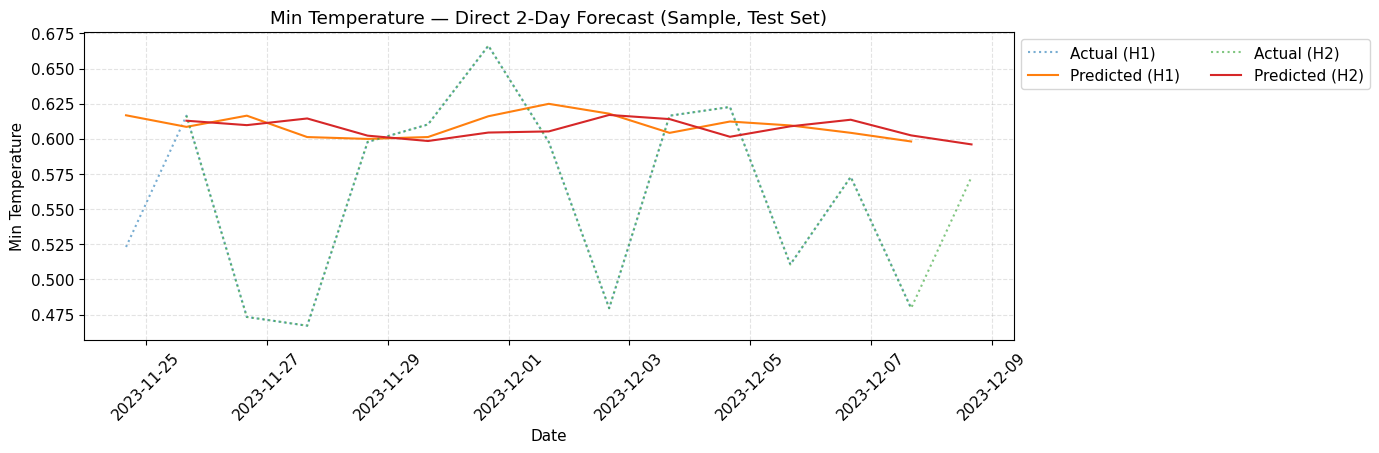

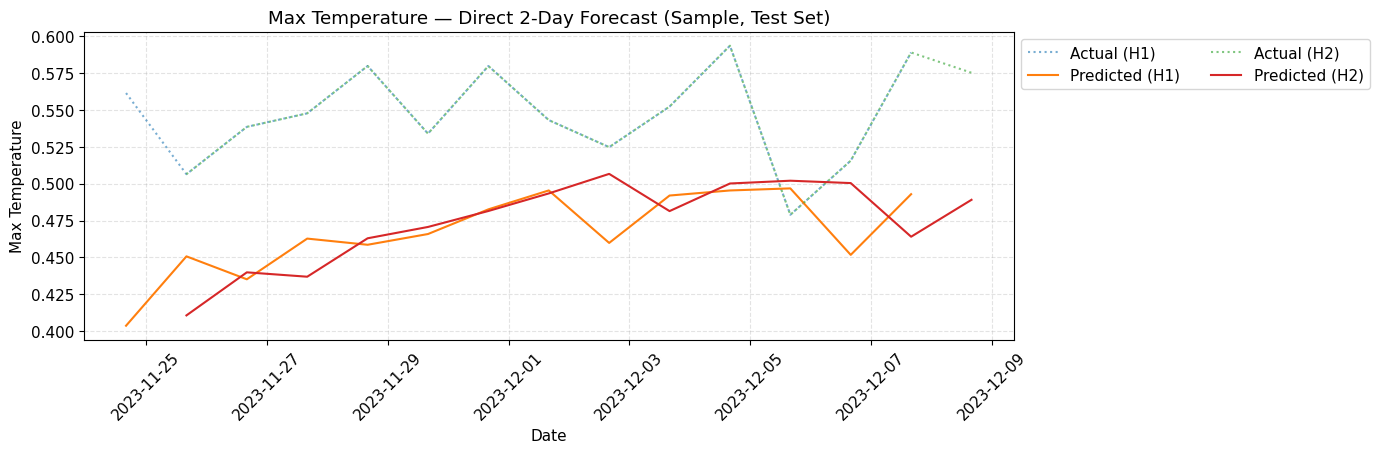

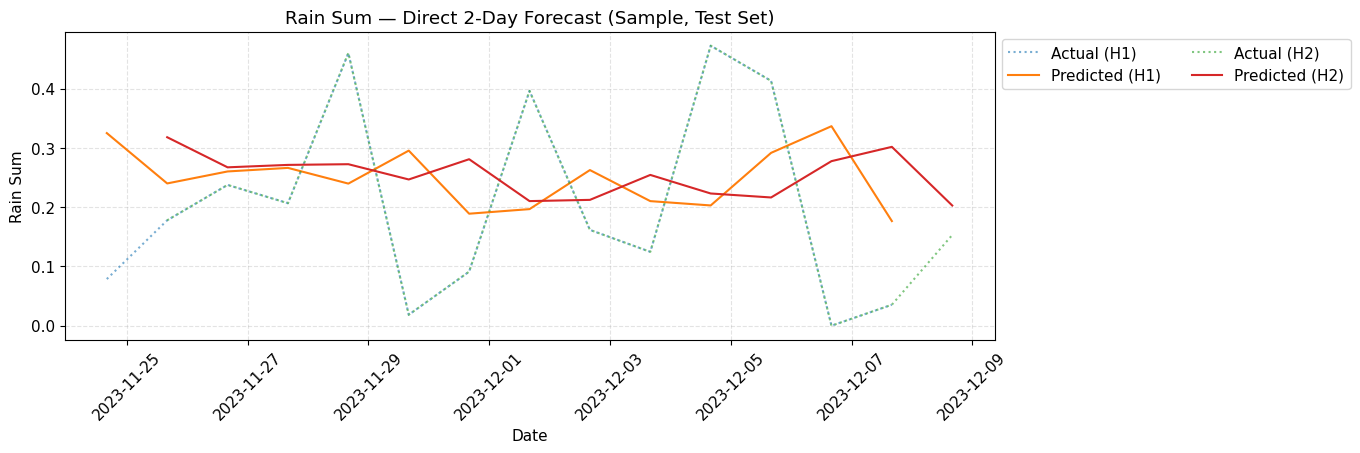

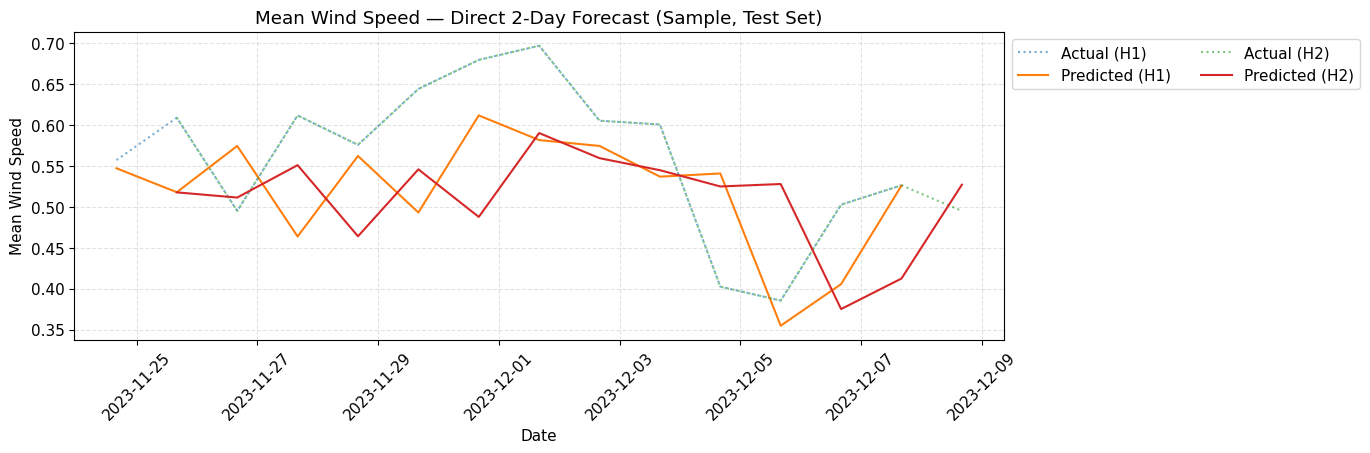

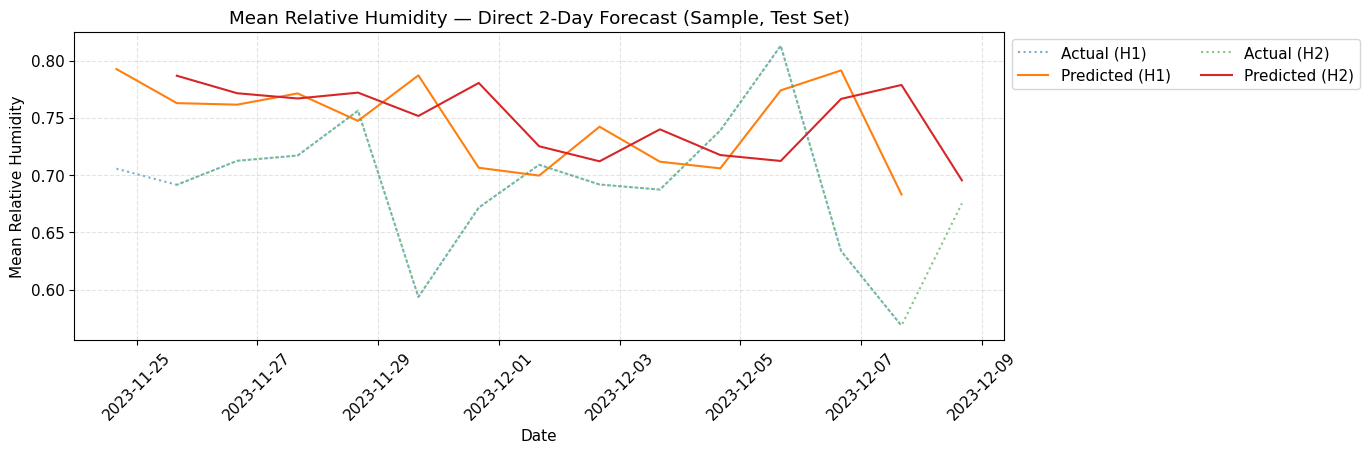

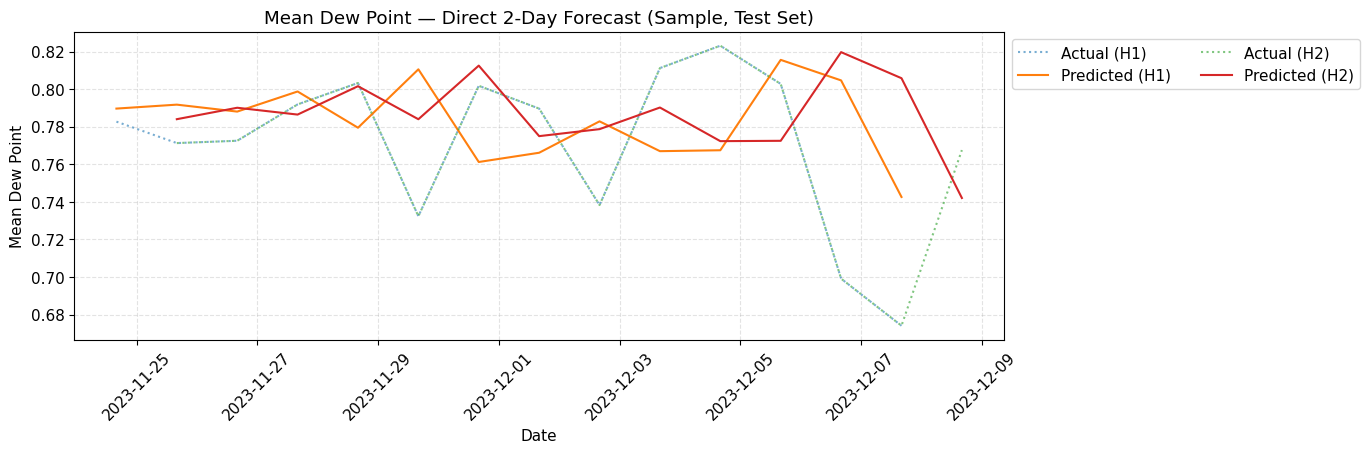

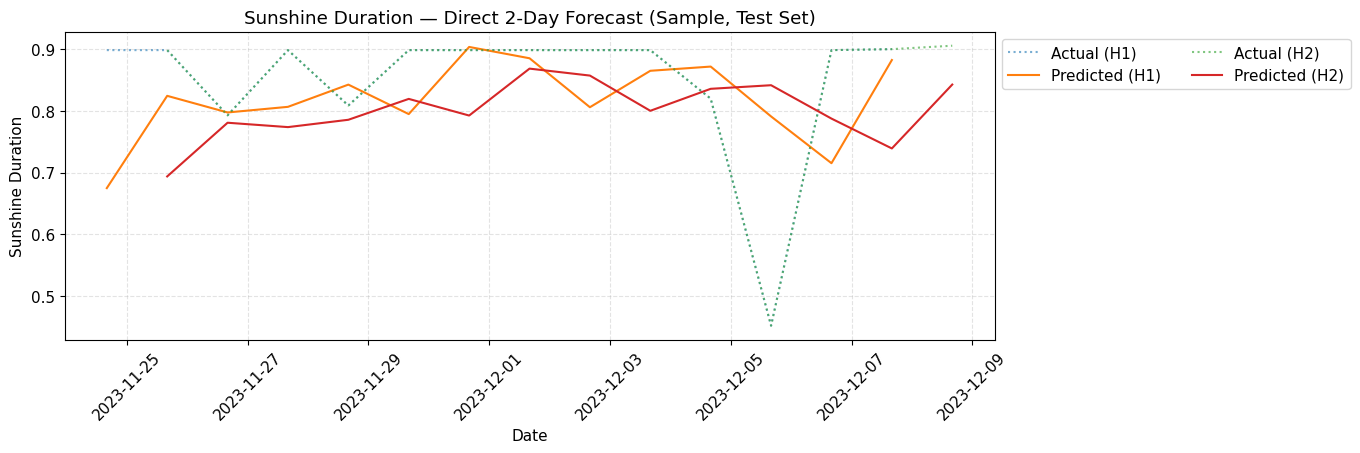

In [29]:
def plot_sample_direct2_predictions(
    target_dates_subset,
    y_true_raw_subset: np.ndarray,
    y_pred_raw_subset: np.ndarray,
    feature_idx: int,
    feature_name: str,
    n_sequences_to_plot: int = 20,
):
    """
    Plot horizon-1 and horizon-2 predictions for selected feature over a subset of sequences.
    Each sequence contributes up to 2 target points.
    """
    n = min(n_sequences_to_plot, len(target_dates_subset))

    rows = []
    for s in range(n):
        for h in range(y_true_raw_subset.shape[1]):
            rows.append({
                "date": pd.to_datetime(target_dates_subset[s][h]),
                "horizon": h + 1,
                "actual": y_true_raw_subset[s, h, feature_idx],
                "predicted": y_pred_raw_subset[s, h, feature_idx],
            })
    plot_df = pd.DataFrame(rows).sort_values(["date", "horizon"])

    plt.figure(figsize=(12,4))
    for h in sorted(plot_df["horizon"].unique()):
        sub = plot_df[plot_df["horizon"] == h]
        plt.plot(sub["date"], sub["actual"], linestyle=":", label=f"Actual (H{h})", alpha=0.6)
        plt.plot(sub["date"], sub["predicted"], label=f"Predicted (H{h})")

    plt.title(f"{feature_name} — Direct 2-Day Forecast (Sample, Test Set)")
    plt.xlabel("Date")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    plt.legend(ncol=2, bbox_to_anchor=(1,1), loc="upper left")
    plt.show()

# Example plots for a few variables (edit as needed)
for feat_idx, feature in enumerate(FEATURE_DISPLAY_NAMES):  # min temp, max temp, rain, sunshine
    plot_sample_direct2_predictions(td_test, y_true_test_raw, y_pred_test_raw, feat_idx, feature, n_sequences_to_plot=14)

In [31]:
for i in range(3):
    print(td_test[i])

[Timestamp('2023-11-24 16:00:00+0000', tz='UTC')
 Timestamp('2023-11-25 16:00:00+0000', tz='UTC')]
[Timestamp('2023-11-25 16:00:00+0000', tz='UTC')
 Timestamp('2023-11-26 16:00:00+0000', tz='UTC')]
[Timestamp('2023-11-26 16:00:00+0000', tz='UTC')
 Timestamp('2023-11-27 16:00:00+0000', tz='UTC')]


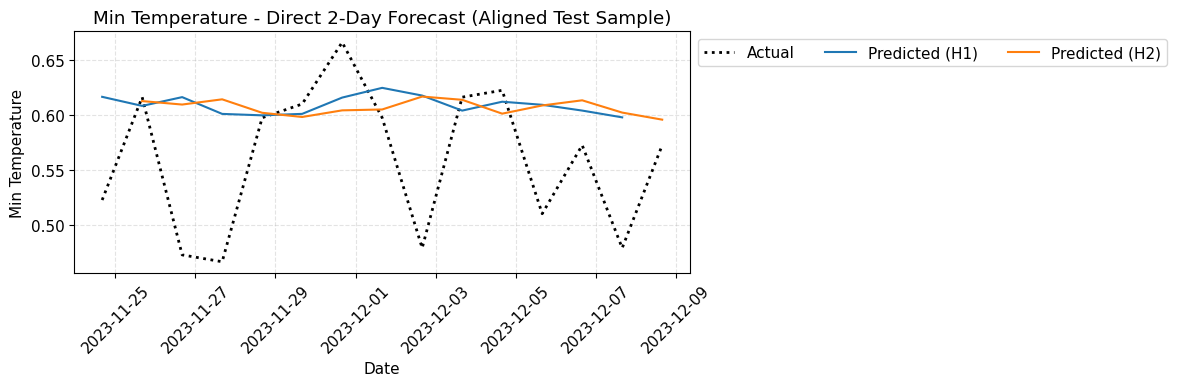

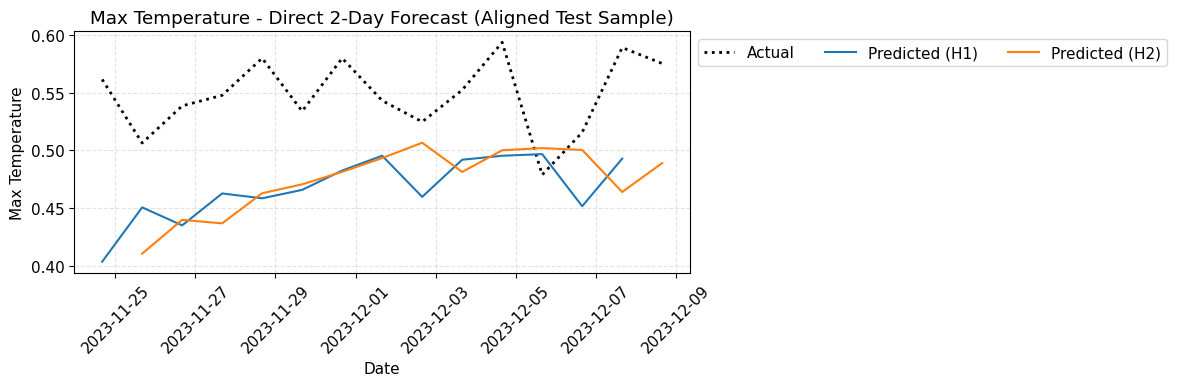

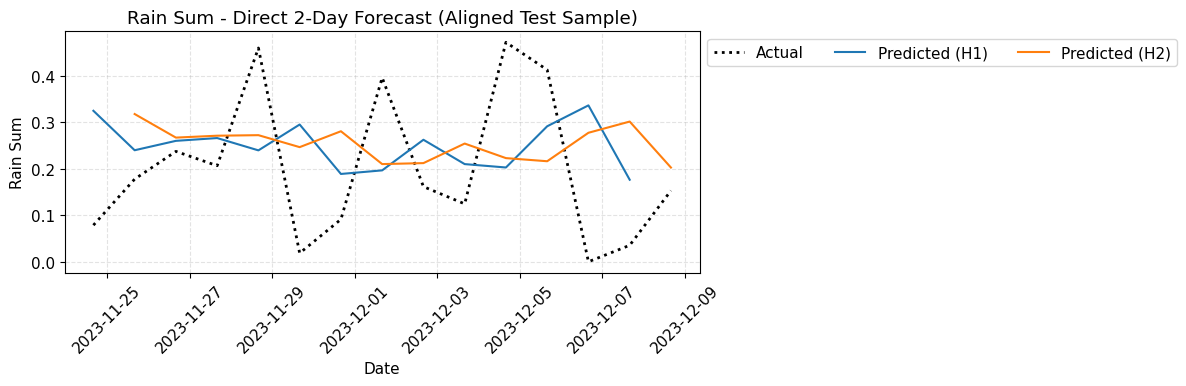

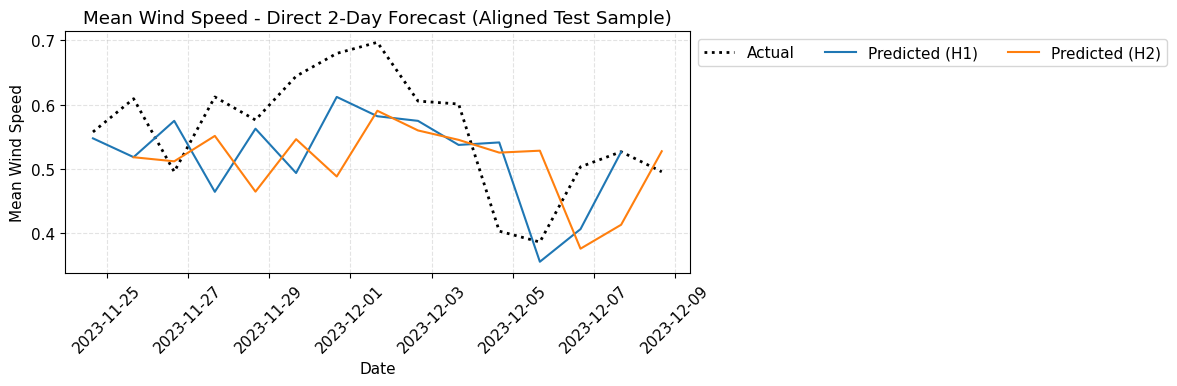

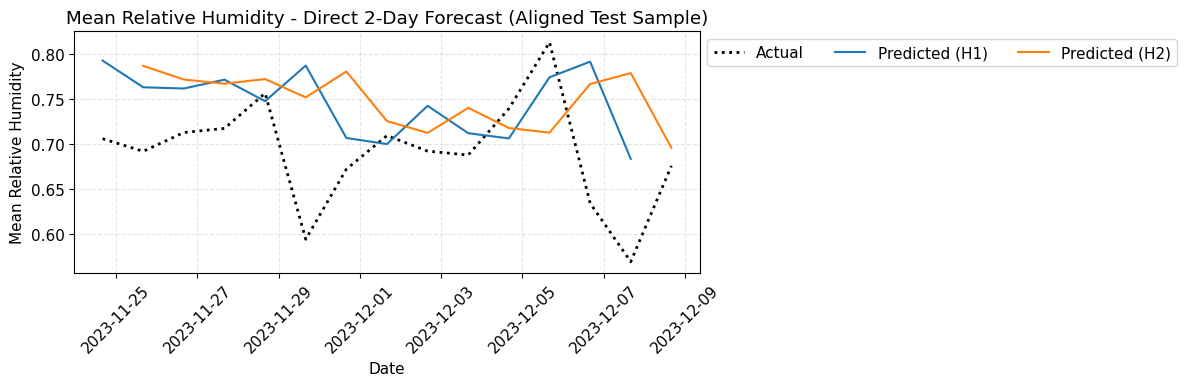

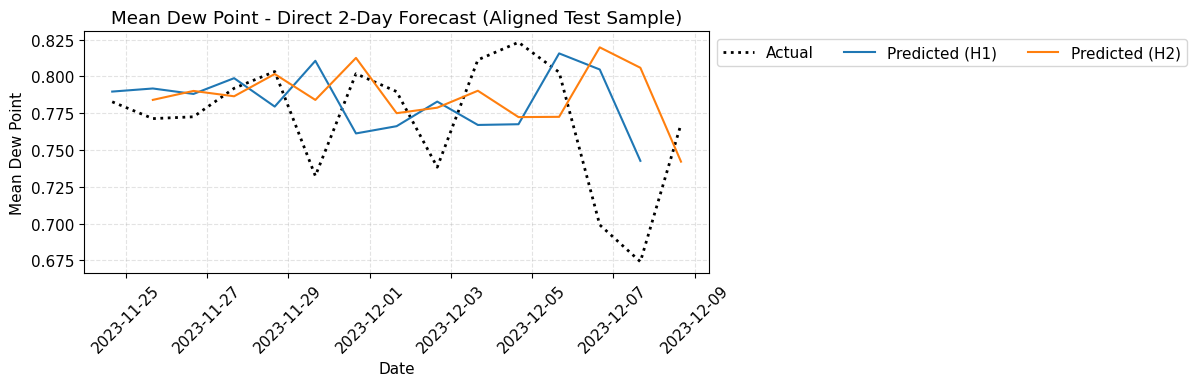

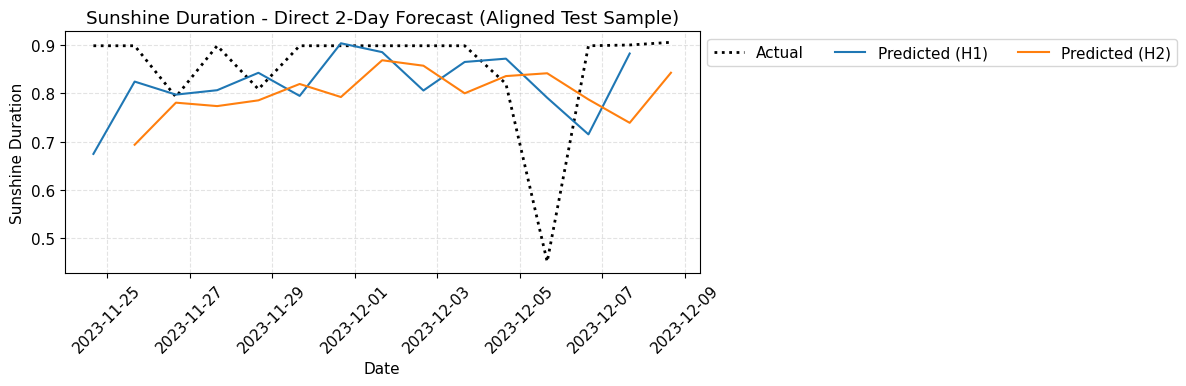

In [30]:
def plot_sample_direct2_predictions_aligned(
    target_dates_subset,
    y_true_raw_subset: np.ndarray,
    y_pred_raw_subset: np.ndarray,
    feature_idx: int,
    feature_name: str,
    n_sequences_to_plot: int = 20,
):
    """
    Plot aligned direct 2-day predictions for one feature.

    This collapses duplicate target dates created by overlapping sequences:
    - Actual values are averaged per date
    - Predicted values are averaged per date and horizon
    """
    n = min(
        n_sequences_to_plot,
        len(target_dates_subset),
        len(y_true_raw_subset),
        len(y_pred_raw_subset),
    )

    rows = []
    for s in range(n):
        for h in range(y_true_raw_subset.shape[1]):
            rows.append(
                {
                    "date": pd.to_datetime(target_dates_subset[s][h]),
                    "horizon": h + 1,
                    "actual": y_true_raw_subset[s, h, feature_idx],
                    "predicted": y_pred_raw_subset[s, h, feature_idx],
                }
            )

    plot_df = pd.DataFrame(rows).sort_values(["date", "horizon"])

    # One aligned actual value per calendar date
    actual_df = (
        plot_df.groupby("date", as_index=False)["actual"]
        .mean()
        .sort_values("date")
    )

    # One aligned predicted value per date and horizon
    pred_df = (
        plot_df.groupby(["date", "horizon"], as_index=False)["predicted"]
        .mean()
        .sort_values(["date", "horizon"])
    )

    plt.figure(figsize=(12, 4))

    plt.plot(
        actual_df["date"],
        actual_df["actual"],
        linestyle=":",
        color="black",
        linewidth=2,
        label="Actual",
    )

    for h in sorted(pred_df["horizon"].unique()):
        sub = pred_df[pred_df["horizon"] == h]
        plt.plot(sub["date"], sub["predicted"], label=f"Predicted (H{h})")

    plt.title(f"{feature_name} - Direct 2-Day Forecast (Aligned Test Sample)")
    plt.xlabel("Date")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    plt.legend(ncol=3, bbox_to_anchor=(1, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


for feat_idx, feature in enumerate(FEATURE_DISPLAY_NAMES):
    plot_sample_direct2_predictions_aligned(
        td_test,
        y_true_test_raw,
        y_pred_test_raw,
        feat_idx,
        feature,
        n_sequences_to_plot=14,
    )


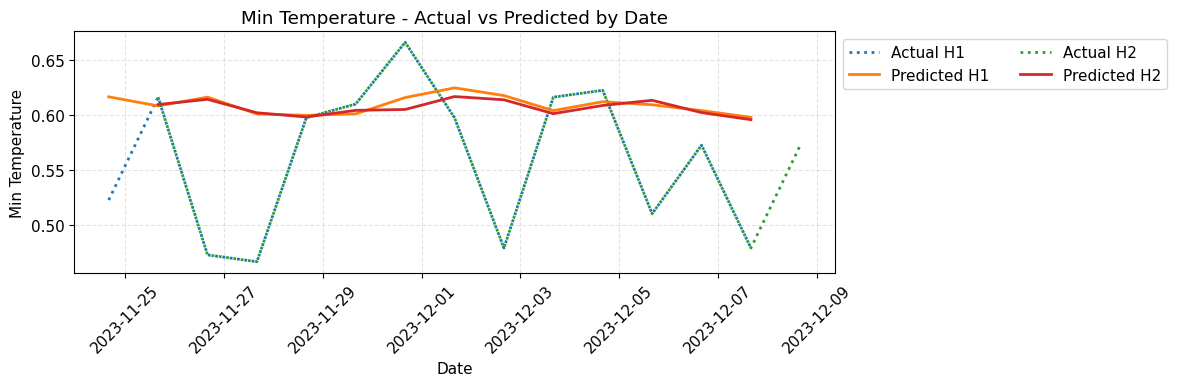

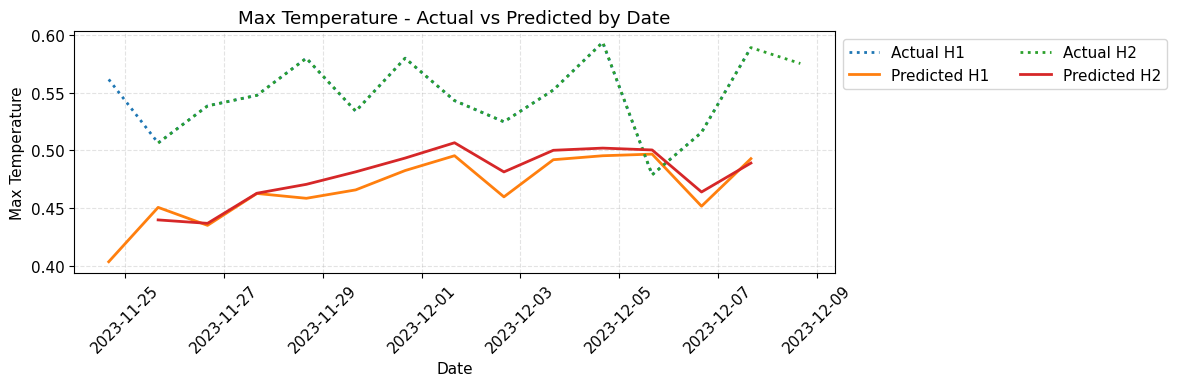

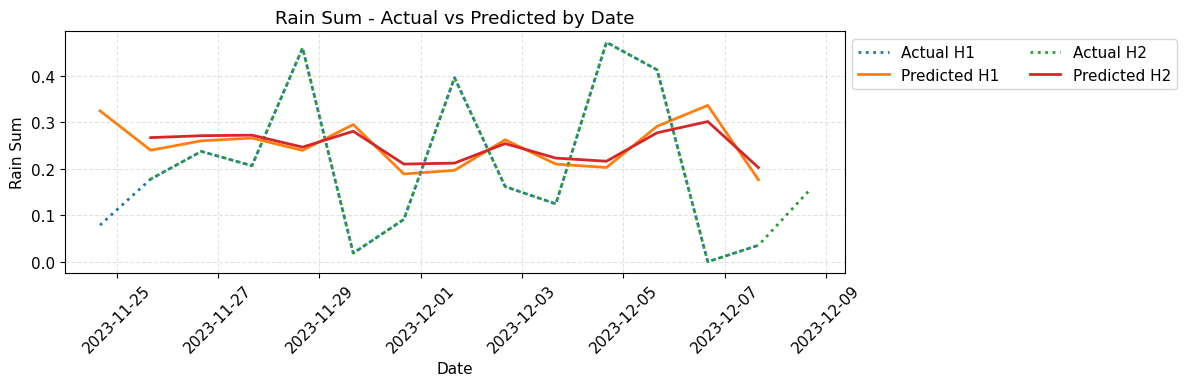

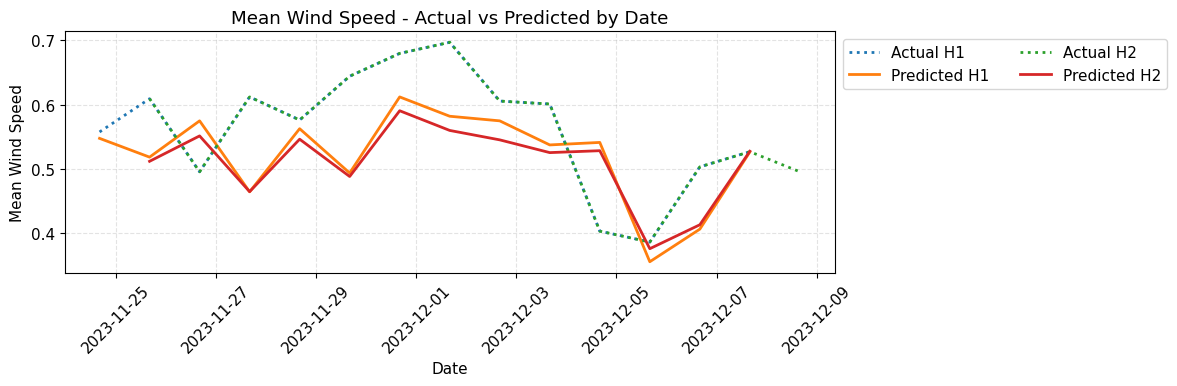

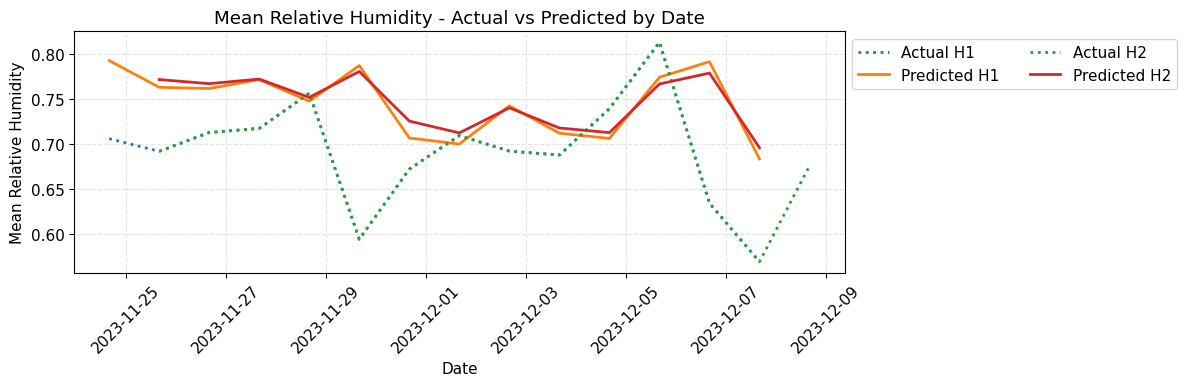

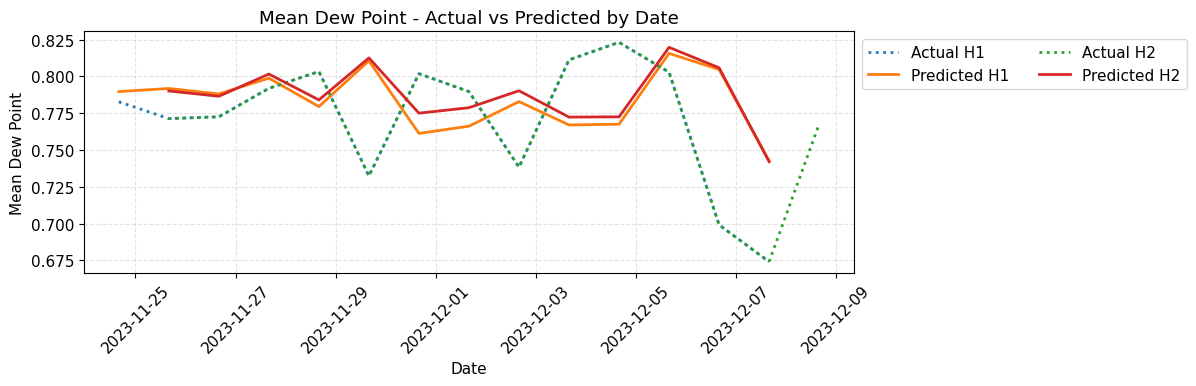

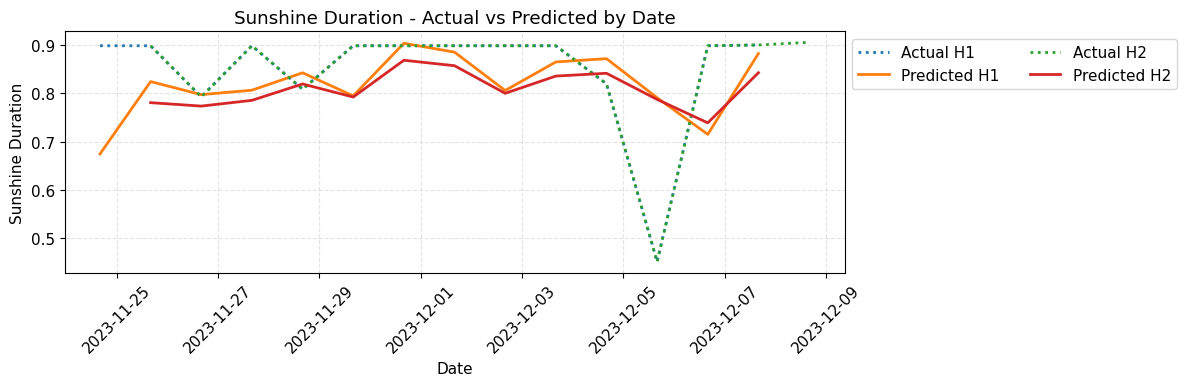

In [100]:
def plot_direct2_horizons_aligned(
    target_dates_subset,
    y_true_raw_subset: np.ndarray,
    y_pred_raw_subset: np.ndarray,
    feature_idx: int,
    feature_name: str,
    n_sequences_to_plot: int = 20,
):
    def resolve_target_date(td_subset, seq_idx, horizon_idx):
        td = target_dates_subset[seq_idx]

        if isinstance(td, (list, tuple, np.ndarray, pd.Index)):
            td_arr = np.asarray(td).ravel()
            if len(td_arr) > horizon_idx:
                return pd.to_datetime(td_arr[horizon_idx])

        base_date = pd.to_datetime(td)
        return base_date + pd.Timedelta(days=horizon_idx + 1)

    n = min(
        n_sequences_to_plot,
        len(target_dates_subset),
        len(y_true_raw_subset),
        len(y_pred_raw_subset),
    )

    actual_rows = []
    pred_rows = []

    for s in range(n):
        for h in range(y_true_raw_subset.shape[1]):
            horizon = h + 1
            target_date = resolve_target_date(target_dates_subset, s, h)

            actual_rows.append({
                "date": target_date,
                "horizon": horizon,
                "actual": y_true_raw_subset[s, h, feature_idx],
            })

            pred_date = target_date - pd.Timedelta(days=1) if horizon == 2 else target_date
            pred_rows.append({
                "date": pred_date,
                "horizon": horizon,
                "predicted": y_pred_raw_subset[s, h, feature_idx],
            })

    actual_df = (
        pd.DataFrame(actual_rows)
        .groupby(["date", "horizon"], as_index=False)["actual"]
        .mean()
    )

    pred_df = (
        pd.DataFrame(pred_rows)
        .groupby(["date", "horizon"], as_index=False)["predicted"]
        .mean()
    )

    plt.figure(figsize=(12, 4))

    for horizon in sorted(actual_df["horizon"].unique()):
        actual_sub = actual_df[actual_df["horizon"] == horizon].sort_values("date")
        pred_sub = pred_df[pred_df["horizon"] == horizon].sort_values("date").reset_index(drop=True)

        # Cut only the prediction head
        head_cut = 1 if horizon == 2 else 0
        pred_sub = pred_sub.iloc[head_cut:].reset_index(drop=True)

        plt.plot(
            actual_sub["date"],
            actual_sub["actual"],
            linestyle=":",
            linewidth=2,
            label=f"Actual H{horizon}",
        )
        plt.plot(
            pred_sub["date"],
            pred_sub["predicted"],
            linewidth=2,
            label=f"Predicted H{horizon}",
        )

    plt.title(f"{feature_name} - Actual vs Predicted by Date")
    plt.xlabel("Date")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    plt.legend(ncol=2, bbox_to_anchor=(1, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



for feat_idx, feature in enumerate(FEATURE_DISPLAY_NAMES):
    plot_direct2_horizons_aligned(
        td_test,
        y_true_test_raw,
        y_pred_test_raw,
        feat_idx,
        feature,
        n_sequences_to_plot=14,
    )


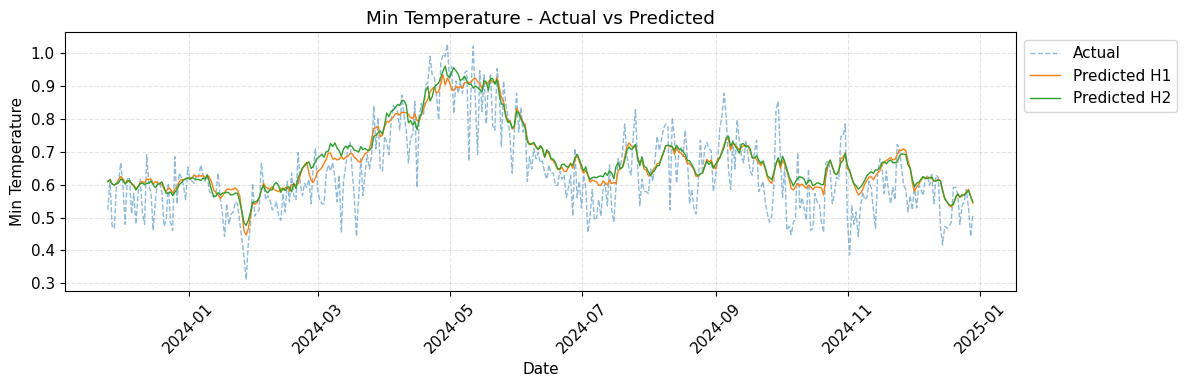

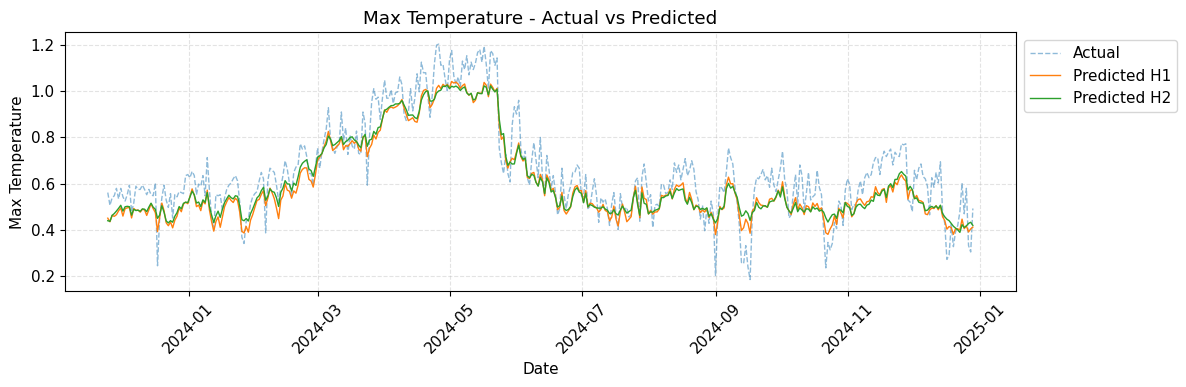

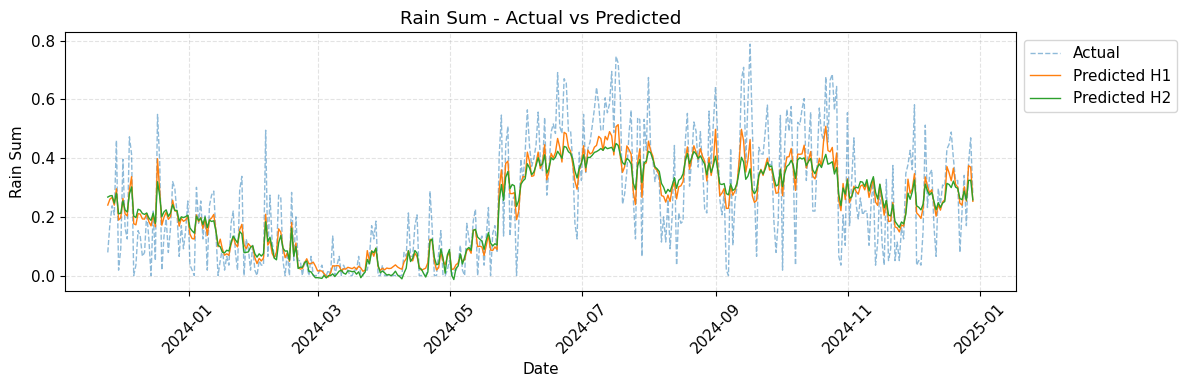

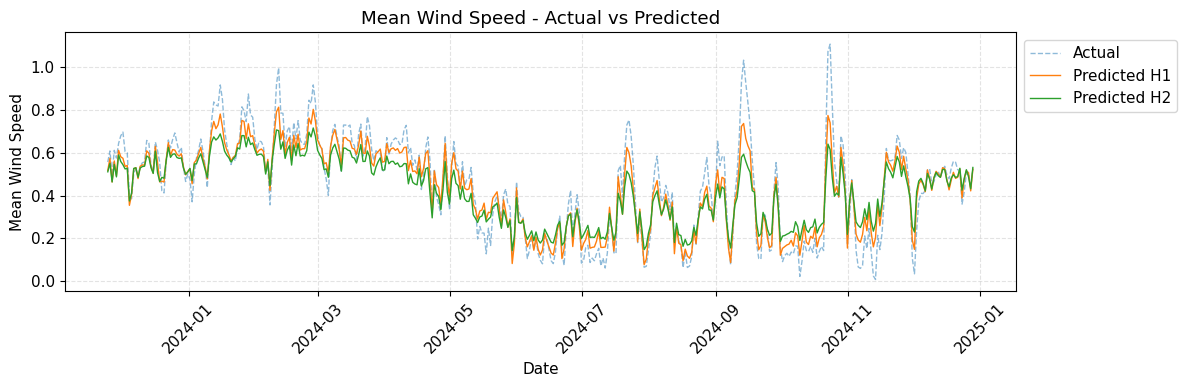

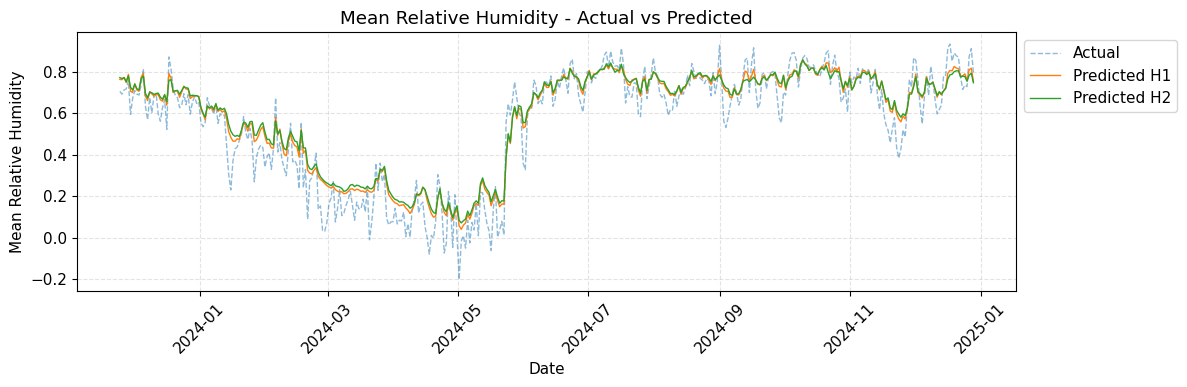

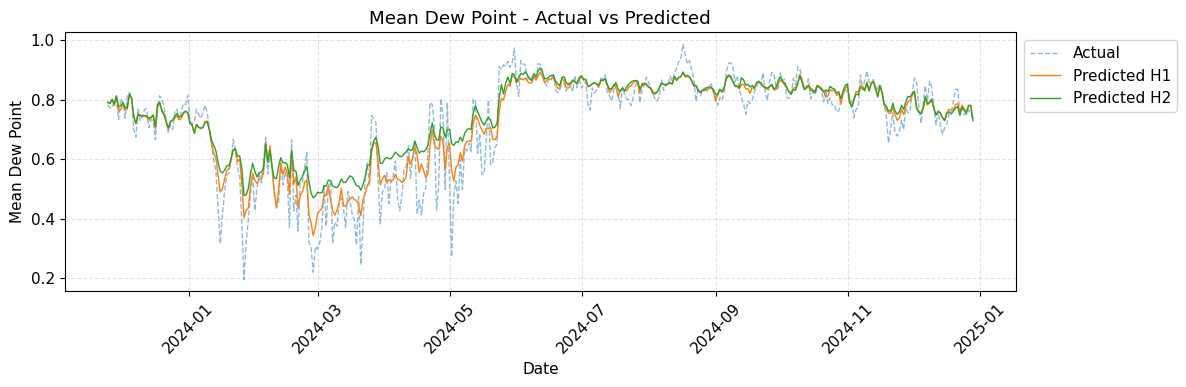

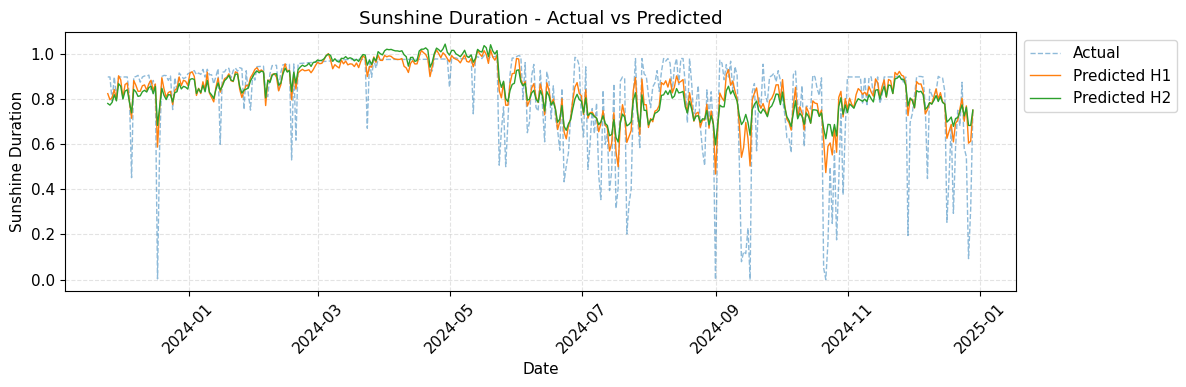

In [124]:
def plot_direct2_predictions_aligned(
    target_dates_subset,
    y_true_raw_subset: np.ndarray,
    y_pred_raw_subset: np.ndarray,
    feature_idx: int,
    feature_name: str,
    n_sequences_to_plot: Optional[int] = None,
):
    def resolve_target_date(td_subset, seq_idx, horizon_idx):
        td = td_subset[seq_idx]

        if isinstance(td, (list, tuple, np.ndarray, pd.Index)):
            td_arr = np.asarray(td).ravel()
            if len(td_arr) > horizon_idx:
                return pd.to_datetime(td_arr[horizon_idx])

        base_date = pd.to_datetime(td)
        return base_date + pd.Timedelta(days=horizon_idx + 1)
    n_total = min(len(target_dates_subset), len(y_true_raw_subset), len(y_pred_raw_subset))
    n = n_total if n_sequences_to_plot is None else min(n_sequences_to_plot, n_total)

    if y_true_raw_subset.shape[1] < 2:
        raise ValueError("This plot expects at least 2 forecast horizons.")

    rows = []
    for s in range(n):
        for h in range(y_true_raw_subset.shape[1]):
            rows.append({
                "date": resolve_target_date(target_dates_subset, s, h),
                "horizon": h + 1,
                "actual": y_true_raw_subset[s, h, feature_idx],
                "predicted": y_pred_raw_subset[s, h, feature_idx],
            })

    source_df = (
        pd.DataFrame(rows)
        .groupby(["date", "horizon"], as_index=False)[["actual", "predicted"]]
        .mean()
        .sort_values(["date", "horizon"])
    )

    actual_df = (
        source_df.groupby("date", as_index=False)["actual"]
        .mean()
        .sort_values("date")
        .reset_index(drop=True)
    )

    pred_h1_df = (
        source_df[source_df["horizon"] == 1][["date", "predicted"]]
        .sort_values("date")
        .reset_index(drop=True)
    )

    pred_h2_df = (
        source_df[source_df["horizon"] == 2][["date", "predicted"]]
        .sort_values("date")
        .reset_index(drop=True)
    )

    if len(actual_df) > 2:
        actual_df = actual_df.iloc[:-2].reset_index(drop=True)
    else:
        actual_df = actual_df.iloc[0:0].copy()

    pred_h1_df = pred_h1_df.iloc[1:].reset_index(drop=True)
    pred_h2_df = pred_h2_df.iloc[1:].reset_index(drop=True)

    aligned_dates = actual_df["date"].reset_index(drop=True)
    actual_vals = actual_df["actual"].reset_index(drop=True)
    pred_h1_vals = pred_h1_df["predicted"].reset_index(drop=True)
    pred_h2_vals = pred_h2_df["predicted"].reset_index(drop=True)

    aligned_len = min(len(aligned_dates), len(actual_vals), len(pred_h1_vals), len(pred_h2_vals))
    if aligned_len == 0:
        raise ValueError("No aligned samples remain after applying the requested trims.")

    aligned_df = pd.DataFrame({
        "date": aligned_dates.iloc[:aligned_len].values,
        "Actual": actual_vals.iloc[:aligned_len].values,
        "Predicted H1": pred_h1_vals.iloc[:aligned_len].values,
        "Predicted H2": pred_h2_vals.iloc[:aligned_len].values,
    })

    plt.figure(figsize=(12, 4))
    plt.plot(aligned_df["date"], aligned_df["Actual"], linestyle="--", alpha=0.5, linewidth=1, label="Actual")
    plt.plot(aligned_df["date"], aligned_df["Predicted H1"], linewidth=1, label="Predicted H1")
    plt.plot(aligned_df["date"], aligned_df["Predicted H2"], linewidth=1, label="Predicted H2")

    plt.title(f"{feature_name} - Actual vs Predicted")
    plt.xlabel("Date")
    plt.ylabel(feature_name)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1,1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return aligned_df


for feat_idx, feature in enumerate(FEATURE_DISPLAY_NAMES):
    plot_direct2_predictions_aligned(
        td_test,
        y_true_test_raw,
        y_pred_test_raw,
        feat_idx,
        feature,
        n_sequences_to_plot=1460,
    )


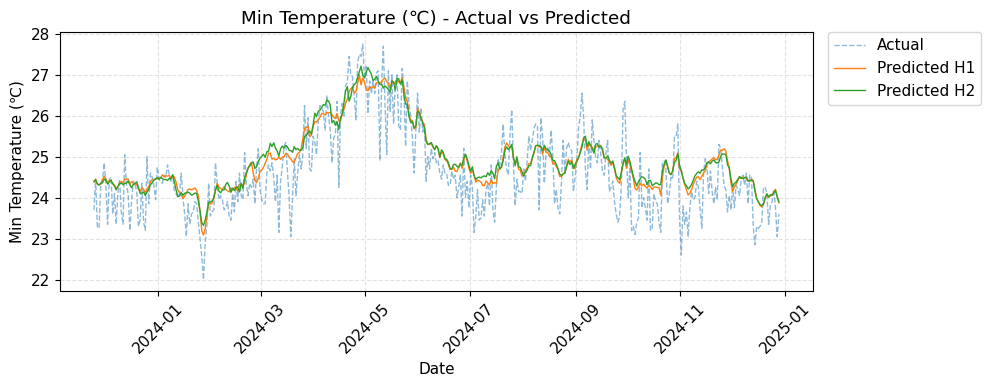

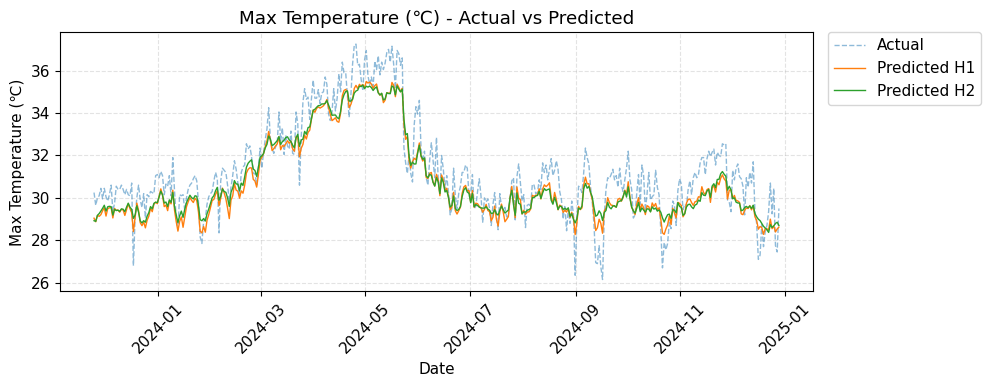

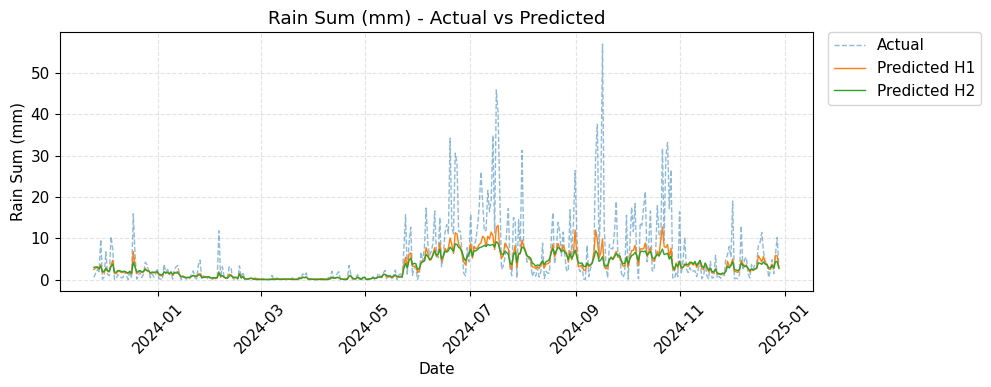

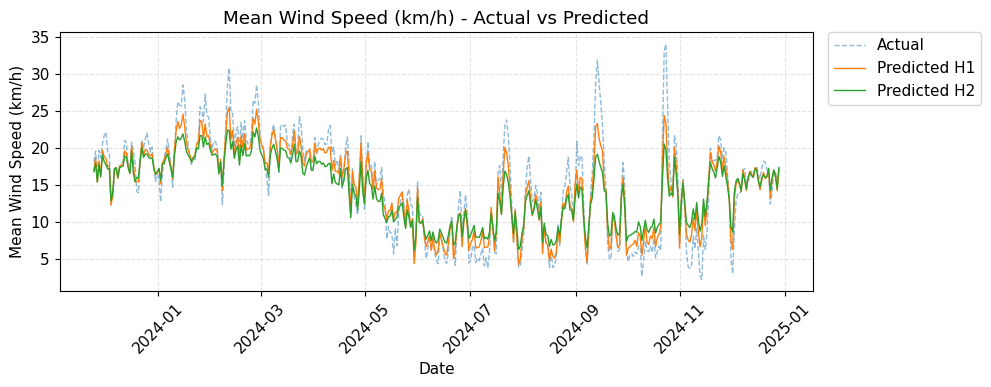

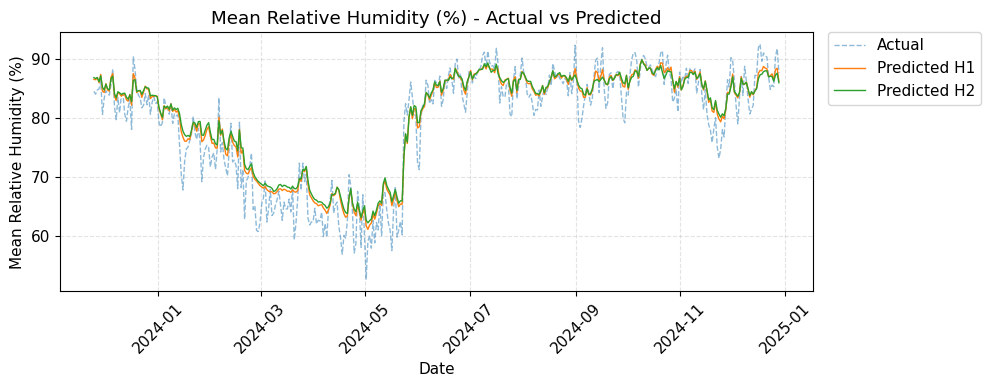

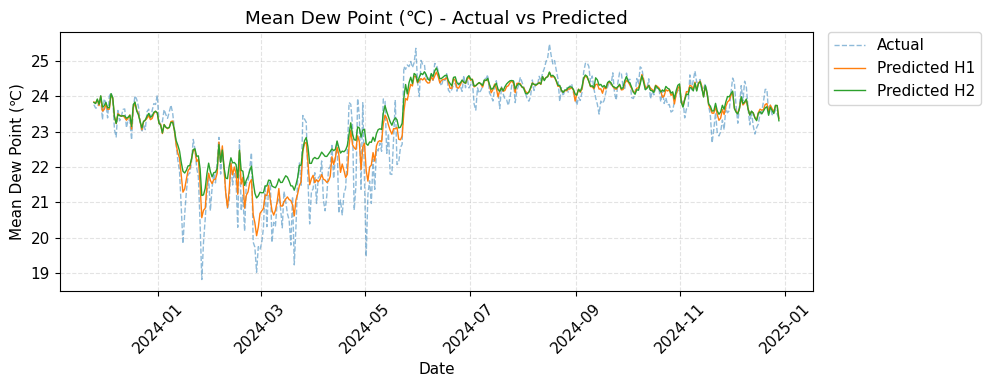

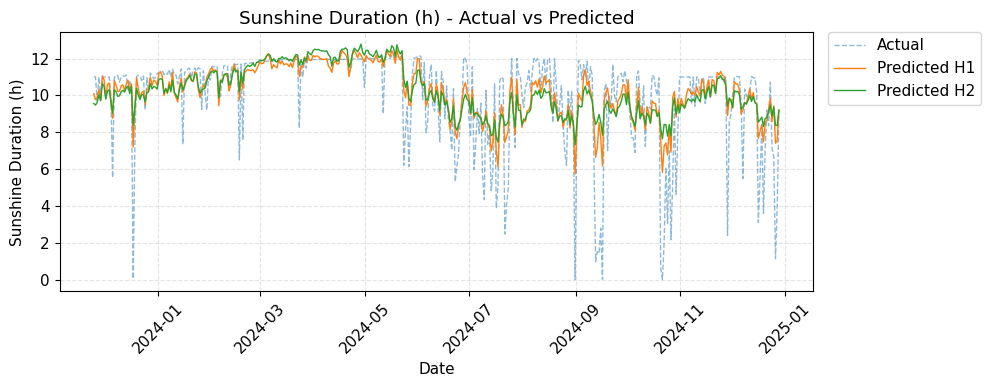

In [156]:
def plot_direct2_predictions_aligned(
    target_dates_subset,
    y_true_raw_subset: np.ndarray,
    y_pred_raw_subset: np.ndarray,
    feature_idx: int,
    feature_name: str,
    n_sequences_to_plot: Optional[int] = None,
):
    """Plot one actual series with aligned H1 and H2 predictions on true dates.

    Alignment rules:
    - build one shared actual-date axis
    - cut 1 point from the head of H1 predictions
    - cut 1 point from the head of H2 predictions because H2 already starts
      one calendar day later in td_test
    - cut 2 points from the tail of the actual series
    - place the trimmed predictions onto the trimmed actual dates
    """
    feature_units = {
        "Min Temperature": "℃",
        "Max Temperature": "℃",
        "Rain Sum": "mm",
        "Mean Wind Speed": "km/h",
        "Mean Relative Humidity": "%",
        "Mean Dew Point": "℃",
        "Sunshine Duration": "h",
    }

    feature_label = feature_name
    if feature_name in feature_units:
        feature_label = f"{feature_name} ({feature_units[feature_name]})"

    def resolve_target_date(td_subset, seq_idx, horizon_idx):
        td = td_subset[seq_idx]

        if isinstance(td, (list, tuple, np.ndarray, pd.Index)):
            td_arr = np.asarray(td).ravel()
            if len(td_arr) > horizon_idx:
                return pd.to_datetime(td_arr[horizon_idx])

        base_date = pd.to_datetime(td)
        return base_date + pd.Timedelta(days=horizon_idx + 1)
    n_total = min(len(target_dates_subset), len(y_true_raw_subset), len(y_pred_raw_subset))
    n = n_total if n_sequences_to_plot is None else min(n_sequences_to_plot, n_total)

    if y_true_raw_subset.shape[1] < 2:
        raise ValueError("This plot expects at least 2 forecast horizons.")

    rows = []
    for s in range(n):
        for h in range(y_true_raw_subset.shape[1]):
            rows.append({
                "date": resolve_target_date(target_dates_subset, s, h),
                "horizon": h + 1,
                "actual": y_true_raw_subset[s, h, feature_idx],
                "predicted": y_pred_raw_subset[s, h, feature_idx],
            })

    source_df = (
        pd.DataFrame(rows)
        .groupby(["date", "horizon"], as_index=False)[["actual", "predicted"]]
        .mean()
        .sort_values(["date", "horizon"])
    )

    actual_df = (
        source_df.groupby("date", as_index=False)["actual"]
        .mean()
        .sort_values("date")
        .reset_index(drop=True)
    )

    pred_h1_df = (
        source_df[source_df["horizon"] == 1][["date", "predicted"]]
        .sort_values("date")
        .reset_index(drop=True)
    )

    pred_h2_df = (
        source_df[source_df["horizon"] == 2][["date", "predicted"]]
        .sort_values("date")
        .reset_index(drop=True)
    )

    if len(actual_df) > 2:
        actual_df = actual_df.iloc[:-2].reset_index(drop=True)
    else:
        actual_df = actual_df.iloc[0:0].copy()

    pred_h1_df = pred_h1_df.iloc[1:].reset_index(drop=True)
    pred_h2_df = pred_h2_df.iloc[1:].reset_index(drop=True)

    aligned_dates = actual_df["date"].reset_index(drop=True)
    actual_vals = actual_df["actual"].reset_index(drop=True)
    pred_h1_vals = pred_h1_df["predicted"].reset_index(drop=True)
    pred_h2_vals = pred_h2_df["predicted"].reset_index(drop=True)

    aligned_len = min(len(aligned_dates), len(actual_vals), len(pred_h1_vals), len(pred_h2_vals))
    if aligned_len == 0:
        raise ValueError("No aligned samples remain after applying the requested trims.")

    aligned_df = pd.DataFrame({
        "date": aligned_dates.iloc[:aligned_len].values,
        "Actual": actual_vals.iloc[:aligned_len].values,
        "Predicted H1": pred_h1_vals.iloc[:aligned_len].values,
        "Predicted H2": pred_h2_vals.iloc[:aligned_len].values,
    })

    plt.figure(figsize=(12, 4))
    plt.plot(aligned_df["date"], aligned_df["Actual"], linestyle="--", alpha=0.5, linewidth=1, label="Actual")
    plt.plot(aligned_df["date"], aligned_df["Predicted H1"], linewidth=1, label="Predicted H1")
    plt.plot(aligned_df["date"], aligned_df["Predicted H2"], linewidth=1, label="Predicted H2")

    plt.title(f"{feature_label} - Actual vs Predicted")
    plt.xlabel("Date")
    plt.ylabel(feature_label)
    plt.xticks(rotation=45)
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.0)
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    plt.show()

    return aligned_df


# Inverse-transform once so the plot uses original units instead of normalized values.
y_true_test_plot = inverse_targets_to_original_units(
    y_true_test_raw,
    y_scaler,
    TARGET_COLS_MODEL,
)
y_pred_test_plot = inverse_targets_to_original_units(
    y_pred_test_raw,
    y_scaler,
    TARGET_COLS_MODEL,
)

for feat_idx, feature in enumerate(FEATURE_DISPLAY_NAMES):
    plot_direct2_predictions_aligned(
        td_test,
        y_true_test_plot,
        y_pred_test_plot,
        feat_idx,
        feature,
        n_sequences_to_plot=1460,
    )
